# Physics-Informed PPO Ablation Notebook

This notebook is organized by **where the physics is injected**:

1. **State ablations**: add physics-derived state features such as tracking error, velocity error, acceleration error.
2. **Reward ablations**: keep the basic observation space fixed and change only physics-informed reward terms.
3. **Architecture ablations**: change temporal/architectural access to dynamics through observation stacking.
4. **Loss-function ablations**: keep deployment observations fixed and add training-only auxiliary dynamics losses.

The notebook separates formulation quality from training or plumbing bugs by running a gate after each family: expected variant count, focused scenario count, finite metrics, failure rate, and artifact completeness including transparency-ratio plots.


In [1]:
from __future__ import annotations

import os
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd()
if not (ROOT / "matlab_literal_env").exists():
    ROOT = Path(r"C:/Users/aha173/OneDrive - American University of Beirut/research/TeleopProject/TeleopDocs/TeleopWithRL")

RESULTS = ROOT / "matlab_literal_env" / "policy_gradient_experiments" / "results" / "dyn"
NOTEBOOK_RUNS_STUDIES = False

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)
print(f"ROOT = {ROOT}")
print(f"RESULTS = {RESULTS}")


ROOT = C:\Users\aha173\OneDrive - American University of Beirut\research\TeleopProject\TeleopDocs\TeleopWithRL
RESULTS = C:\Users\aha173\OneDrive - American University of Beirut\research\TeleopProject\TeleopDocs\TeleopWithRL\matlab_literal_env\policy_gradient_experiments\results\dyn


## Shared Gate Helpers

A result family is treated as usable only if the summary has every expected variant, each variant has the expected focused scenario count, and each focused folder contains per-scenario histories plus transparency-ratio plots. Low performance can still be a real result; missing rows, missing plots, non-finite metrics, or impossible budgets are treated as training/plumbing problems.


In [2]:
def _long_path(path: str | Path) -> str | Path:
    path = Path(path)
    if os.name != "nt":
        return path
    text = str(path.resolve())
    if text.startswith("\\\\?\\"):
        return text
    if text.startswith("\\\\"):
        return "\\\\?\\UNC\\" + text.lstrip("\\")
    return "\\\\?\\" + text


def file_exists(path: str | Path) -> bool:
    try:
        with open(_long_path(path), "rb"):
            return True
    except FileNotFoundError:
        return False


def load_summary(study_dir: Path) -> pd.DataFrame:
    csv_path = study_dir / "summary.csv"
    if not file_exists(csv_path):
        raise FileNotFoundError(csv_path)
    return pd.read_csv(_long_path(csv_path))


def artifact_audit(study_dir: Path, variant_dirs: list[str]) -> pd.DataFrame:
    rows = []
    for key in variant_dirs:
        focused = study_dir / key / "focused_eval"
        rows.append({
            "variant_dir": key,
            "metrics_csv": file_exists(focused / "focused_eval_metrics.csv"),
            "history_npz_count": len(list((focused / "histories").glob("*.npz"))),
            "transparency_plot_count": len(list(focused.rglob("*transparency_ratio.png"))),
            "scenario_png_count": len(list((focused / "plots" / "scenarios").glob("*.png"))),
        })
    return pd.DataFrame(rows)


def summarize_gate(name: str, df: pd.DataFrame, expected_keys: list[str], audit: pd.DataFrame, expected_scenarios: int = 25) -> pd.DataFrame:
    key_col = "key"
    present = set(df[key_col].astype(str)) if key_col in df else set()
    rows = []
    rows.append({"gate": "expected_rows", "pass": len(df) == len(expected_keys), "detail": f"{len(df)} / {len(expected_keys)} rows"})
    rows.append({"gate": "expected_keys", "pass": set(expected_keys).issubset(present), "detail": ", ".join(k for k in expected_keys if k not in present) or "all present"})
    if "focused_scenario_count" in df:
        scenario_ok = pd.to_numeric(df["focused_scenario_count"], errors="coerce").fillna(-1).eq(expected_scenarios).all()
        rows.append({"gate": "focused_scenarios", "pass": bool(scenario_ok), "detail": f"expected {expected_scenarios} per row"})
    metric_cols = [c for c in ["focused_tracking_rmse_mm", "focused_transparency_ratio_error_rmse", "focused_failure_rate"] if c in df.columns]
    if metric_cols:
        finite = np.isfinite(df[metric_cols].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=float)).all()
        rows.append({"gate": "finite_metrics", "pass": bool(finite), "detail": ", ".join(metric_cols)})
    if "focused_failure_rate" in df:
        failure = pd.to_numeric(df["focused_failure_rate"], errors="coerce")
        in_range = ((failure >= 0.0) & (failure <= 1.0)).all()
        rows.append({"gate": "failure_rate_range", "pass": bool(in_range), "detail": f"min={failure.min():.3g}, max={failure.max():.3g}"})
    rows.append({"gate": "history_artifacts", "pass": bool(audit["history_npz_count"].eq(expected_scenarios).all()), "detail": f"min={audit['history_npz_count'].min()}, max={audit['history_npz_count'].max()}"})
    rows.append({"gate": "transparency_plots", "pass": bool(audit["transparency_plot_count"].eq(expected_scenarios).all()), "detail": f"min={audit['transparency_plot_count'].min()}, max={audit['transparency_plot_count'].max()}"})
    rows.append({"gate": "scenario_pngs", "pass": bool(audit["scenario_png_count"].eq(expected_scenarios * 5).all()), "detail": f"min={audit['scenario_png_count'].min()}, max={audit['scenario_png_count'].max()}"})
    gate = pd.DataFrame(rows)
    display(Markdown(f"**{name} gate:** {'PASS' if gate['pass'].all() else 'CHECK'}"))
    display(gate)
    return gate


def show_image(path: Path, title: str | None = None):
    if file_exists(path):
        if title:
            display(Markdown(f"**{title}**"))
        with open(_long_path(path), "rb") as fh:
            display(Image(data=fh.read()))
    else:
        display(Markdown(f"Missing image: `{path}`"))


In [3]:
STATE_DIR = RESULTS / "physics_informed_formulations_01"
REWARD_DIR = RESULTS / "physics_reward_ablation_basic_obs_02"
ARCH_DIR = RESULTS / "temporal_observation_stack_01"
LOSS_DIR = RESULTS / "physics_auxiliary_gru_ppo_01"

STATE_KEYS = ["F0_baseline", "F1_error_state_reward", "F2_error_dot_state_reward", "F3_error_ddot_state_reward", "F4_accel_state", "F5_accel_state_reward", "F6_effort_plus_delta_u"]
REWARD_KEYS = ["R0_e_only", "R1_e_edot", "R2_sliding", "R3_sliding_du", "R4_sliding_du_ddu", "R5_second_order", "R6_lyapunov", "R7_phase_direction", "R8_hf_deadzone"]
ARCH_KEYS = ["T0_pos_current", "T1_pos_stack3", "T2_pos_stack5", "T3_posvel_current", "T4_posvel_stack3"]
LOSS_KEYS = ["G0_gru_ppo", "G1_gru_prediction", "G2_gru_hidden_state", "G3_gru_prediction_hidden"]
LOSS_DIR_KEYS = ["G0", "G1p", "G2h", "G3ph"]

STATE_CMD = ["python", "matlab_literal_env/policy_gradient_experiments/run_physics_informed_formulations.py", "--study-name", STATE_DIR.name, "--skip-existing", "--refresh-focused-eval", "--skip-bode", "--ppo-device", "cpu"]
REWARD_CMD = ["python", "matlab_literal_env/policy_gradient_experiments/run_physics_reward_ablation_basic_obs.py", "--study-name", REWARD_DIR.name, "--skip-existing", "--skip-bode", "--ppo-device", "cpu"]
ARCH_CMD = ["python", "matlab_literal_env/policy_gradient_experiments/run_temporal_observation_stack.py", "--study-name", ARCH_DIR.name, "--skip-existing", "--refresh-focused-eval", "--skip-bode", "--ppo-device", "cpu"]
LOSS_CMD = ["python", "matlab_literal_env/policy_gradient_experiments/run_auxiliary_gru_ppo.py", "--study-name", LOSS_DIR.name, "--reward-key", "R5_second_order", "--train-episodes", "64", "--test-episodes", "8", "--eval-episodes", "2", "--eval-every-episodes", "8", "--episode-duration", "30", "--env-switch-time", "10", "--stroke-limit-mode", "clamp", "--device", "cpu", "--skip-existing"]

for label, cmd in [("state", STATE_CMD), ("reward", REWARD_CMD), ("architecture", ARCH_CMD), ("loss", LOSS_CMD)]:
    print(label + ":", " ".join(cmd))
    if NOTEBOOK_RUNS_STUDIES:
        subprocess.run(cmd, cwd=ROOT, check=True)


state: python matlab_literal_env/policy_gradient_experiments/run_physics_informed_formulations.py --study-name physics_informed_formulations_01 --skip-existing --refresh-focused-eval --skip-bode --ppo-device cpu
reward: python matlab_literal_env/policy_gradient_experiments/run_physics_reward_ablation_basic_obs.py --study-name physics_reward_ablation_basic_obs_02 --skip-existing --skip-bode --ppo-device cpu
architecture: python matlab_literal_env/policy_gradient_experiments/run_temporal_observation_stack.py --study-name temporal_observation_stack_01 --skip-existing --refresh-focused-eval --skip-bode --ppo-device cpu
loss: python matlab_literal_env/policy_gradient_experiments/run_auxiliary_gru_ppo.py --study-name physics_auxiliary_gru_ppo_01 --reward-key R5_second_order --train-episodes 64 --test-episodes 8 --eval-episodes 2 --eval-every-episodes 8 --episode-duration 30 --env-switch-time 10 --stroke-limit-mode clamp --device cpu --skip-existing


## 1. State Ablations: Inject Physics Into the Observation

This family changes the policy input state and, in the original formulations, sometimes couples the state feature with a matching reward term. It answers: *does giving the policy physics-derived error coordinates make the controller easier to learn?*

The current state study uses the original 24,576-step budget per variant. It is therefore useful for comparing the original F0-F6 formulations against one another, but it should not be compared directly against the 96k reward/loss studies as a final training-budget claim.


In [4]:
state_summary = load_summary(STATE_DIR)
state_audit = artifact_audit(STATE_DIR, STATE_KEYS)
state_gate = summarize_gate("State ablations", state_summary, STATE_KEYS, state_audit)

state_cols = ["key", "label", "obs_dim", "total_timesteps", "state_features", "reward_terms", "focused_tracking_rmse_mm", "focused_failure_rate", "focused_transparency_ratio_error_rmse", "focused_transparency_ratio_within_20pct"]
display(state_summary[[c for c in state_cols if c in state_summary.columns]].sort_values("focused_tracking_rmse_mm"))
display(state_audit)


**State ablations gate:** PASS

,gate,pass,detail
0,expected_rows,True,7 / 7 rows
1,expected_keys,True,all present
2,focused_scenarios,True,expected 25 per row
3,finite_metrics,True,"focused_tracking_rmse_mm, focused_transparency..."
4,failure_rate_range,True,"min=0, max=0"
5,history_artifacts,True,"min=25, max=25"
6,transparency_plots,True,"min=25, max=25"
7,scenario_pngs,True,"min=125, max=125"


,key,label,obs_dim,total_timesteps,state_features,reward_terms,focused_tracking_rmse_mm,focused_failure_rate,focused_transparency_ratio_error_rmse,focused_transparency_ratio_within_20pct
2,F2_error_dot_state_reward,Add Error Dot,7,24576,x_m x_s v_m v_s u_v tracking_error velocity_error,tracking_base control_effort physics_error phy...,8.053667,0.0,81.537791,0.051898
1,F1_error_state_reward,Add Error,6,24576,x_m x_s v_m v_s u_v tracking_error,tracking_base control_effort physics_error,8.136565,0.0,263.029159,0.067890
3,F3_error_ddot_state_reward,Add Error DDot,8,24576,x_m x_s v_m v_s u_v tracking_error velocity_er...,tracking_base control_effort physics_error phy...,11.441601,0.0,32.300289,0.005398
0,F0_baseline,Baseline,5,24576,x_m x_s v_m v_s u_v,tracking_base control_effort,20.507394,0.0,62.121174,0.079969
6,F6_effort_plus_delta_u,Effort + Delta U,5,24576,x_m x_s v_m v_s u_v,tracking_base control_effort smooth_delta_u,20.512773,0.0,62.336846,0.079969
5,F5_accel_state_reward,Accel State + Reward,7,24576,x_m x_s v_m v_s u_v x_m_ddot x_s_ddot,tracking_base control_effort acceleration_error,22.563076,0.0,29.425164,0.046250
4,F4_accel_state,Accel State,7,24576,x_m x_s v_m v_s u_v x_m_ddot x_s_ddot,tracking_base control_effort,23.610365,0.0,33.336347,0.045051


,variant_dir,metrics_csv,history_npz_count,transparency_plot_count,scenario_png_count
0,F0_baseline,True,25,25,125
1,F1_error_state_reward,True,25,25,125
2,F2_error_dot_state_reward,True,25,25,125
3,F3_error_ddot_state_reward,True,25,25,125
4,F4_accel_state,True,25,25,125
5,F5_accel_state_reward,True,25,25,125
6,F6_effort_plus_delta_u,True,25,25,125


**State ablation summary**

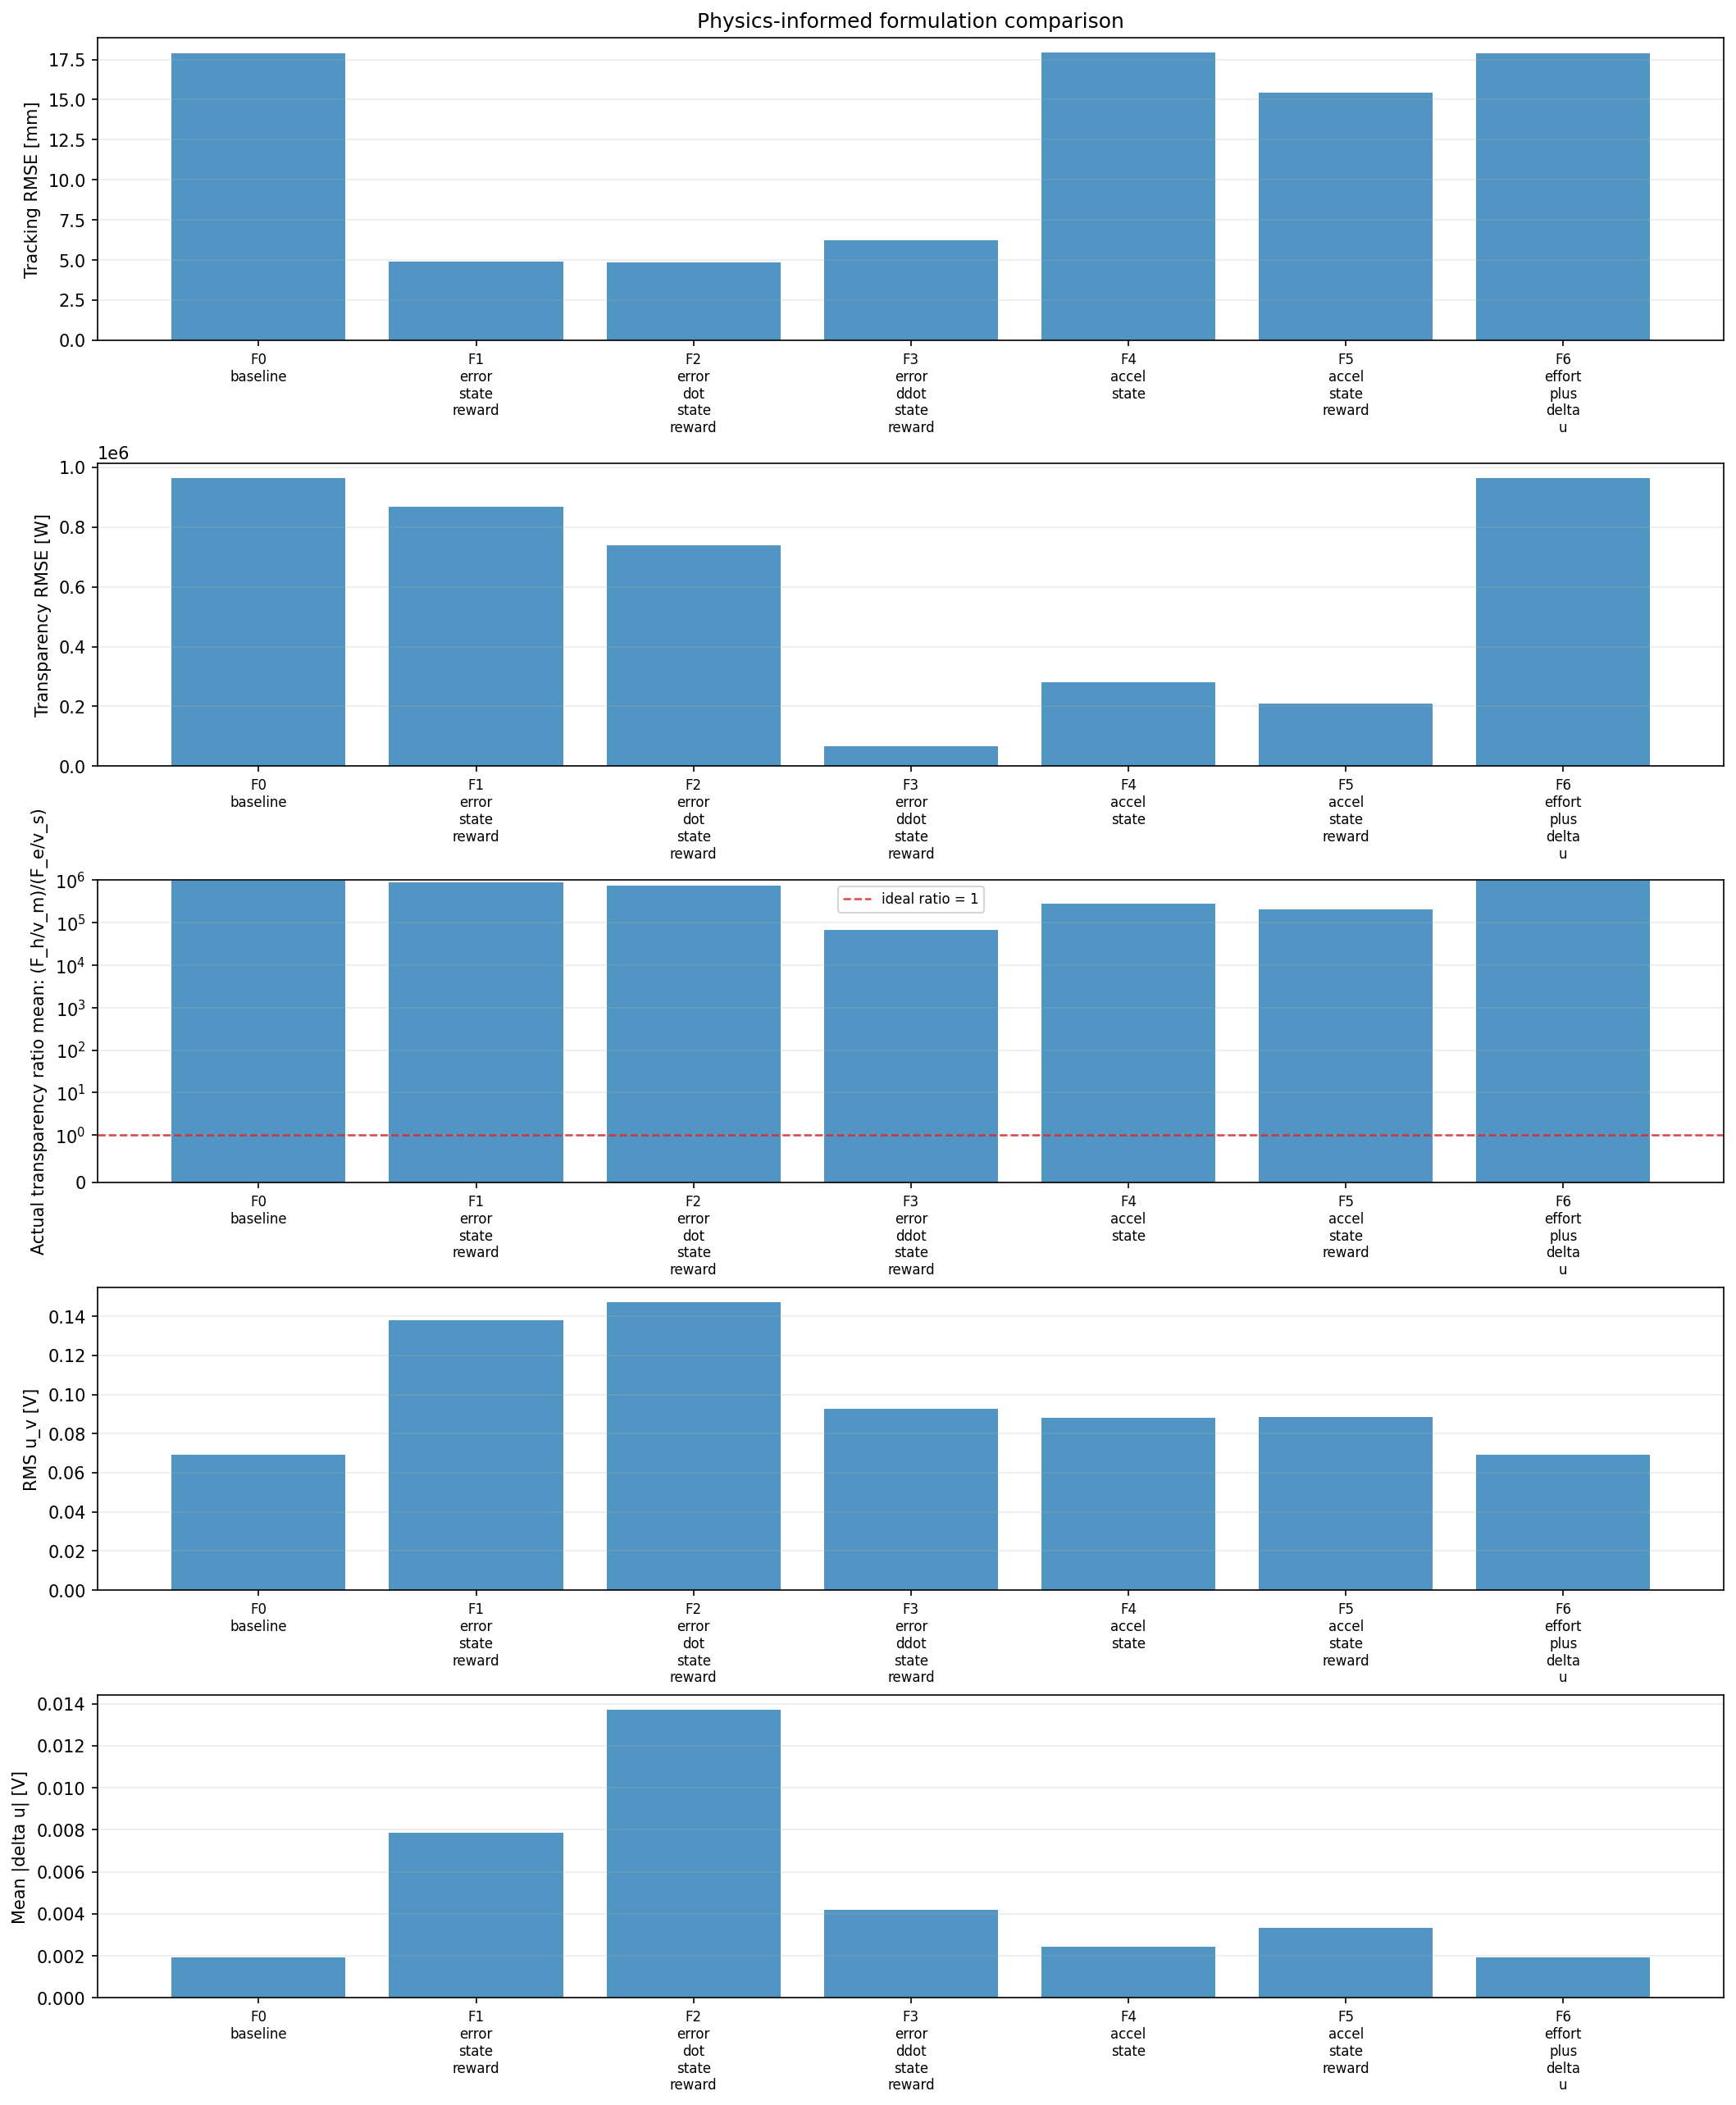

**State ablation learning curves**

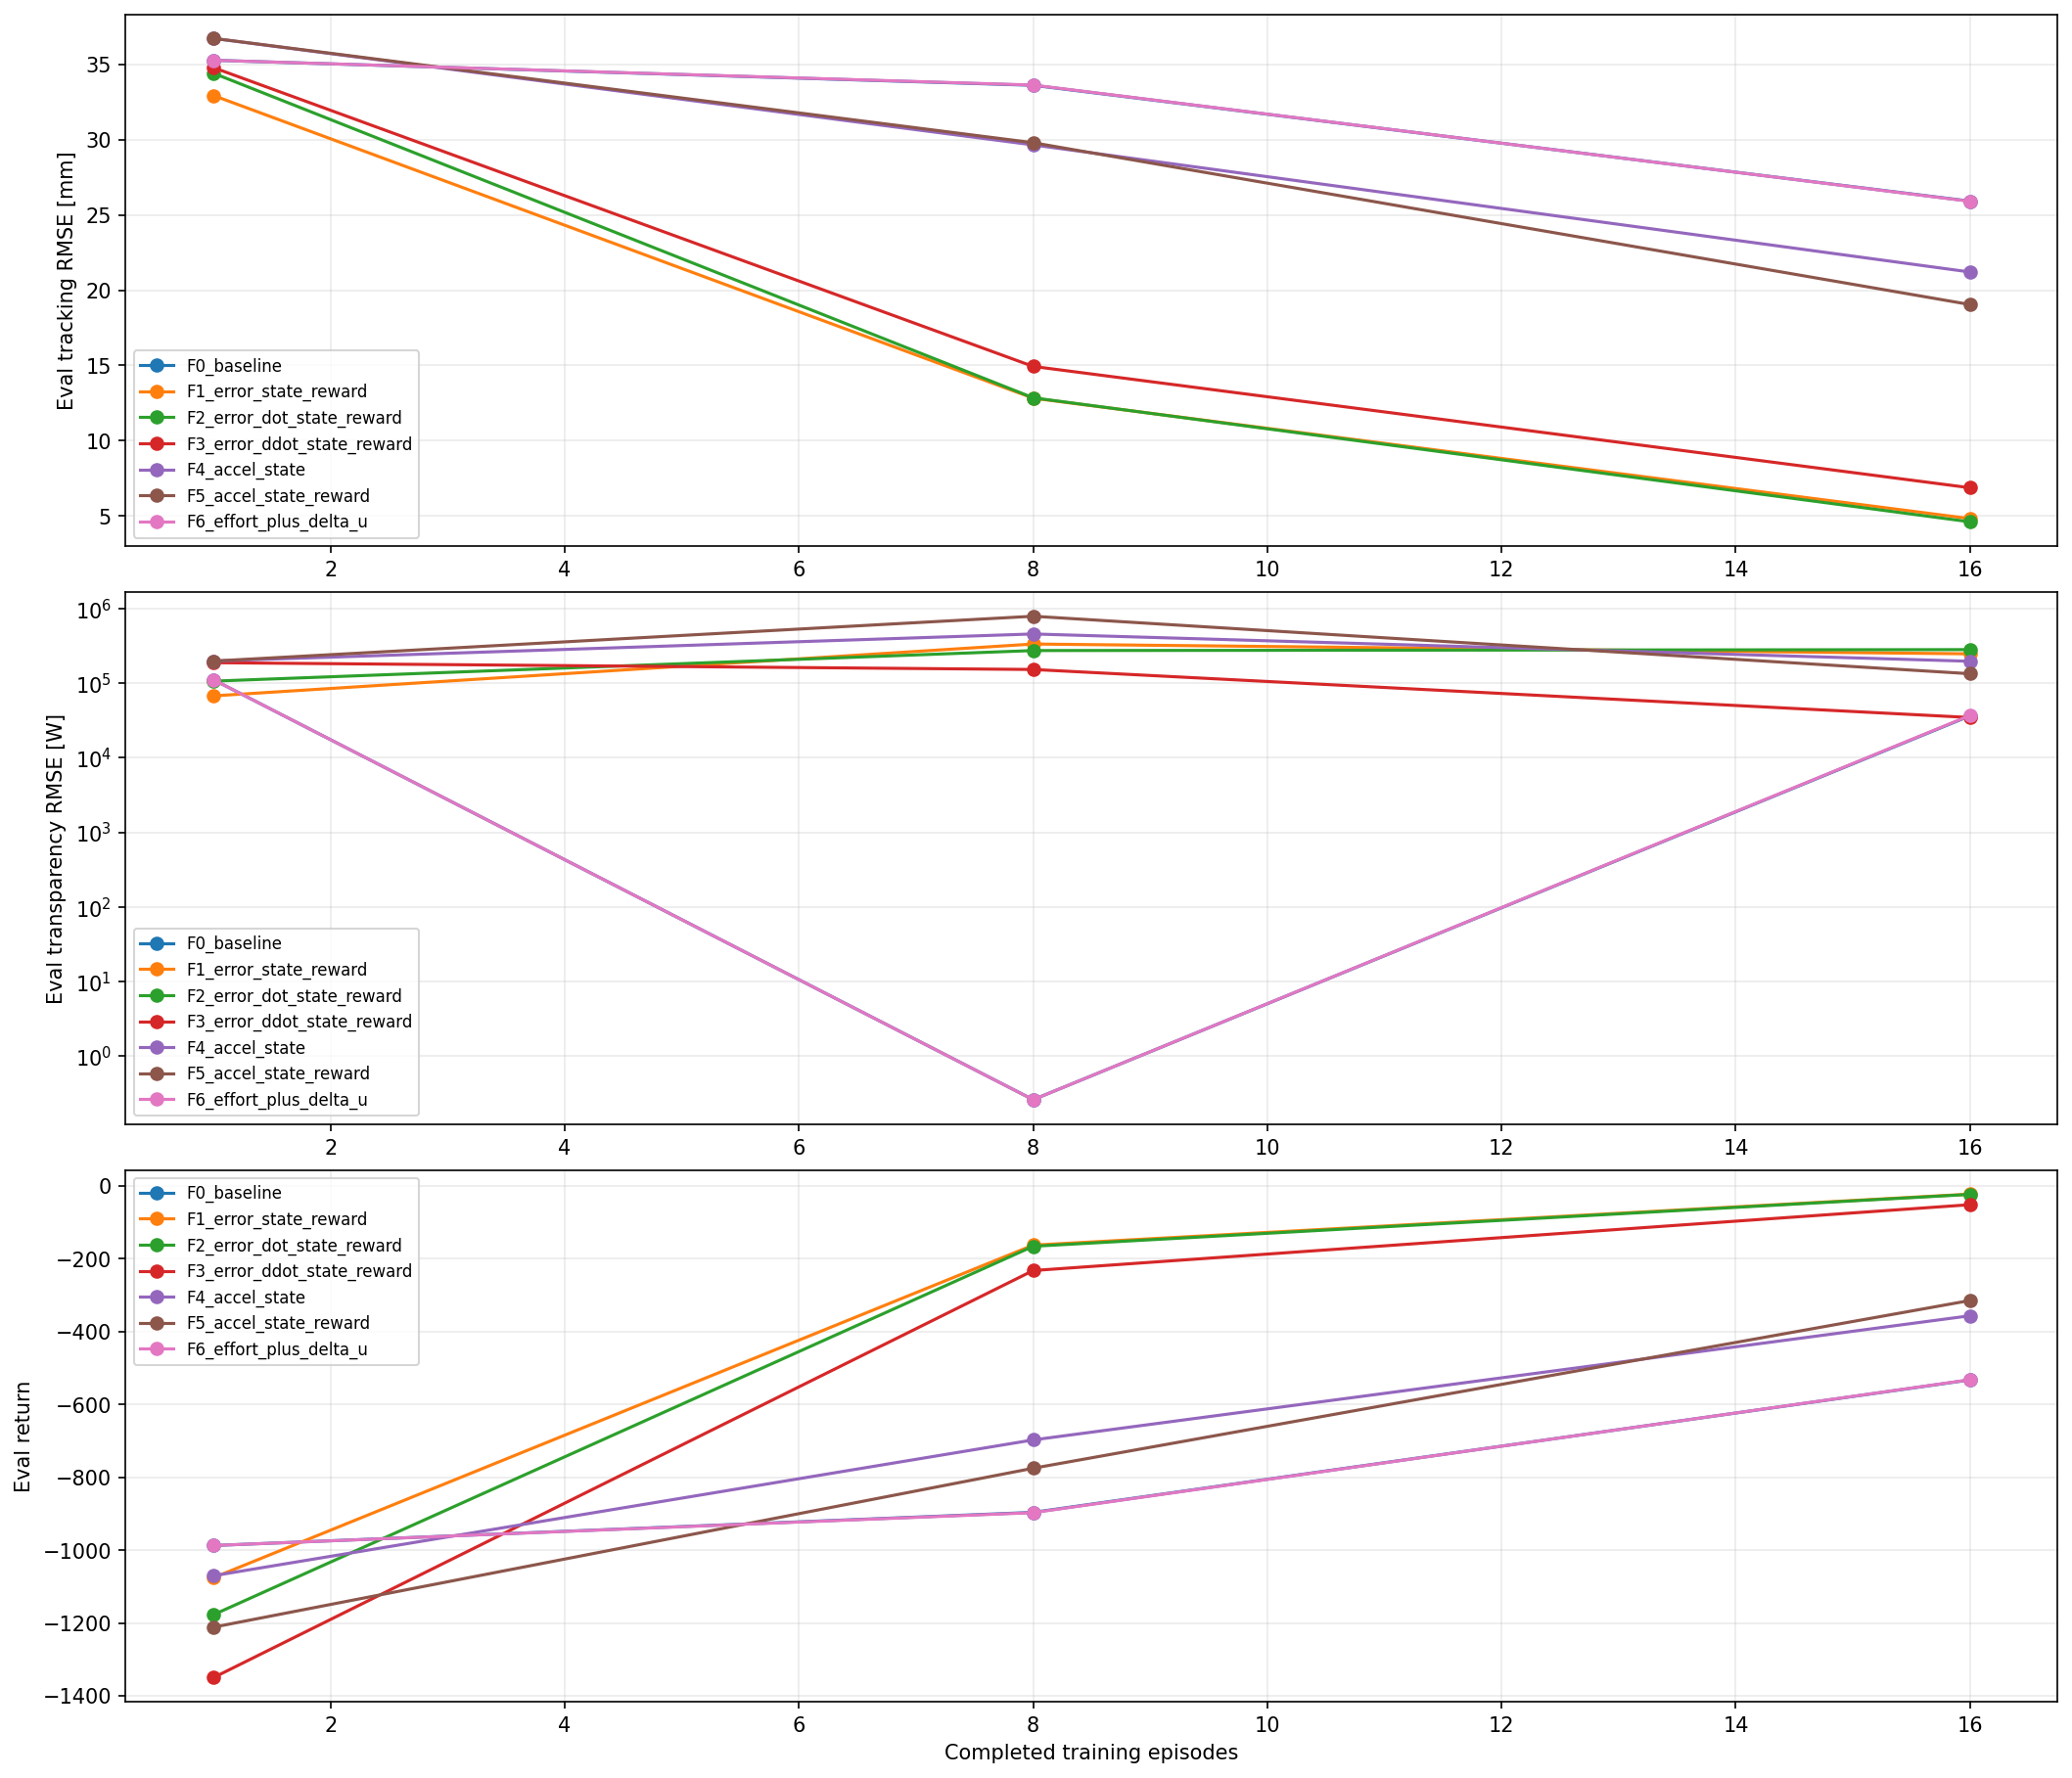

**State sample transparency ratio: F2 nominal**

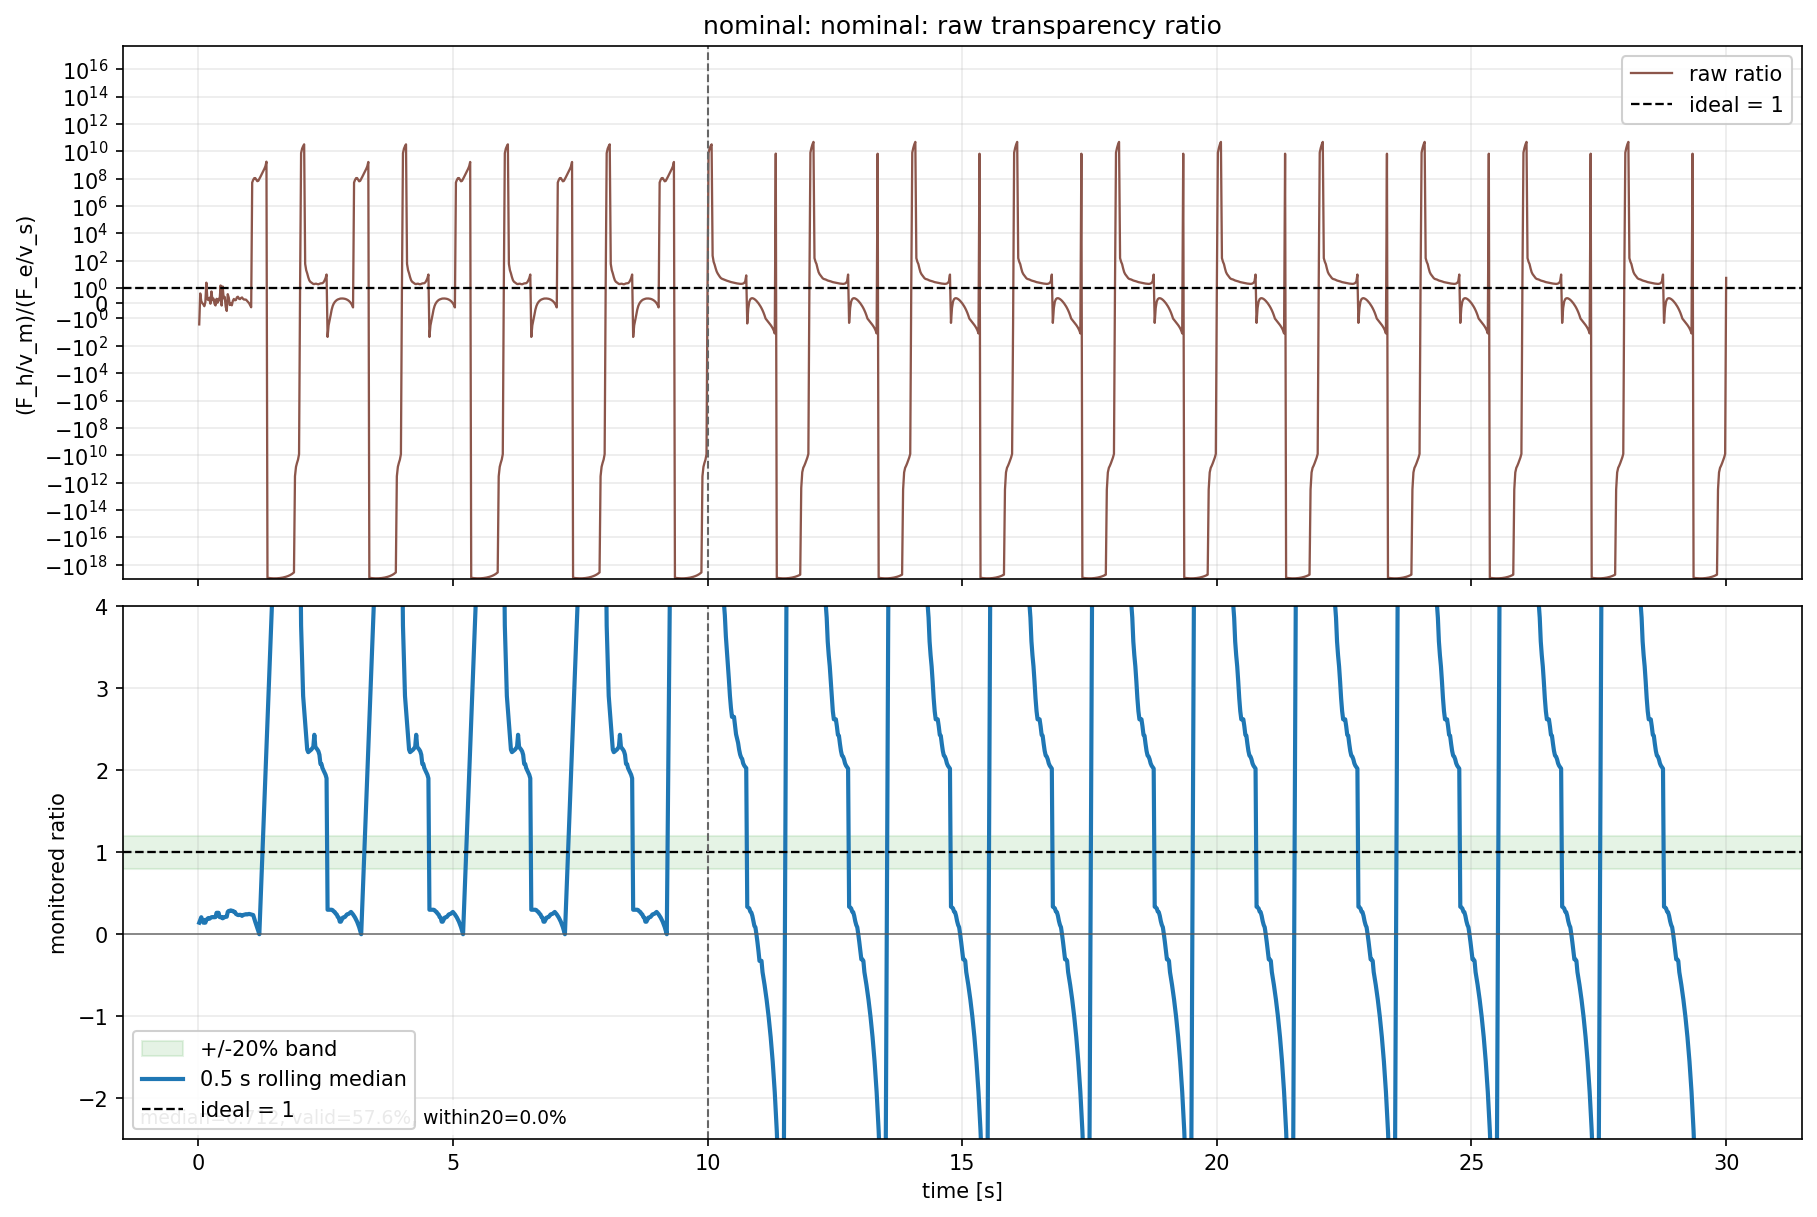

In [5]:
show_image(STATE_DIR / "summary_bars.png", "State ablation summary")
show_image(STATE_DIR / "learning_curves.png", "State ablation learning curves")
show_image(STATE_DIR / "F2_error_dot_state_reward" / "focused_eval" / "plots" / "scenarios" / "nominal_transparency_ratio.png", "State sample transparency ratio: F2 nominal")


## 2. Reward Ablations: Inject Physics Into the Reward

This family fixes the deployed observation to the basic sensor set:

`x_m, x_s, v_m, v_s, u_v`

Only the reward terms change. This is the cleanest test of whether physics-informed closed-loop error dynamics help beyond plain tracking error.


In [6]:
reward_summary = load_summary(REWARD_DIR)
reward_audit = artifact_audit(REWARD_DIR, REWARD_KEYS)
reward_gate = summarize_gate("Reward ablations", reward_summary, REWARD_KEYS, reward_audit)

reward_cols = ["key", "label", "total_timesteps", "reward_terms", "focused_tracking_rmse_mm", "focused_failure_rate", "focused_transparency_ratio_error_rmse", "focused_transparency_ratio_within_20pct", "focused_mean_abs_delta2_u_v"]
display(reward_summary[[c for c in reward_cols if c in reward_summary.columns]].sort_values("focused_tracking_rmse_mm"))
display(reward_audit)


**Reward ablations gate:** PASS

,gate,pass,detail
0,expected_rows,True,9 / 9 rows
1,expected_keys,True,all present
2,focused_scenarios,True,expected 25 per row
3,finite_metrics,True,"focused_tracking_rmse_mm, focused_transparency..."
4,failure_rate_range,True,"min=0, max=0"
5,history_artifacts,True,"min=25, max=25"
6,transparency_plots,True,"min=25, max=25"
7,scenario_pngs,True,"min=125, max=125"


,key,label,total_timesteps,reward_terms,focused_tracking_rmse_mm,focused_failure_rate,focused_transparency_ratio_error_rmse,focused_transparency_ratio_within_20pct,focused_mean_abs_delta2_u_v
5,R5_second_order,Second order,96000,tracking_error sliding_error action_delta acti...,11.223918,0.0,100.990783,0.057346,0.010704
3,R3_sliding_du,Sliding + du,96000,tracking_error sliding_error action_delta,12.184672,0.0,39.592447,0.043862,0.012829
2,R2_sliding,Sliding,96000,tracking_error sliding_error,13.638585,0.0,16.029764,0.045770,0.026105
0,R0_e_only,e only,96000,tracking_error,15.618334,0.0,238.550040,0.043026,19.439241
4,R4_sliding_du_ddu,Sliding + du + ddu,96000,tracking_error sliding_error action_delta acti...,19.029765,0.0,19.266879,0.028253,0.018065
7,R7_phase_direction,Phase + direction,96000,tracking_error sliding_error action_delta acti...,21.015963,0.0,18.877632,0.045008,0.020750
8,R8_hf_deadzone,HF + deadzone,96000,tracking_error_deadzone velocity_error_deadzon...,21.286705,0.0,18.674861,0.043626,0.027658
6,R6_lyapunov,Lyapunov,96000,tracking_error sliding_error action_delta acti...,21.633929,0.0,26.595670,0.043260,0.022781
1,R1_e_edot,e + edot,96000,tracking_error velocity_error,27.600512,0.0,638.167591,0.014066,0.501613


,variant_dir,metrics_csv,history_npz_count,transparency_plot_count,scenario_png_count
0,R0_e_only,True,25,25,125
1,R1_e_edot,True,25,25,125
2,R2_sliding,True,25,25,125
3,R3_sliding_du,True,25,25,125
4,R4_sliding_du_ddu,True,25,25,125
5,R5_second_order,True,25,25,125
6,R6_lyapunov,True,25,25,125
7,R7_phase_direction,True,25,25,125
8,R8_hf_deadzone,True,25,25,125


**Reward ablation summary**

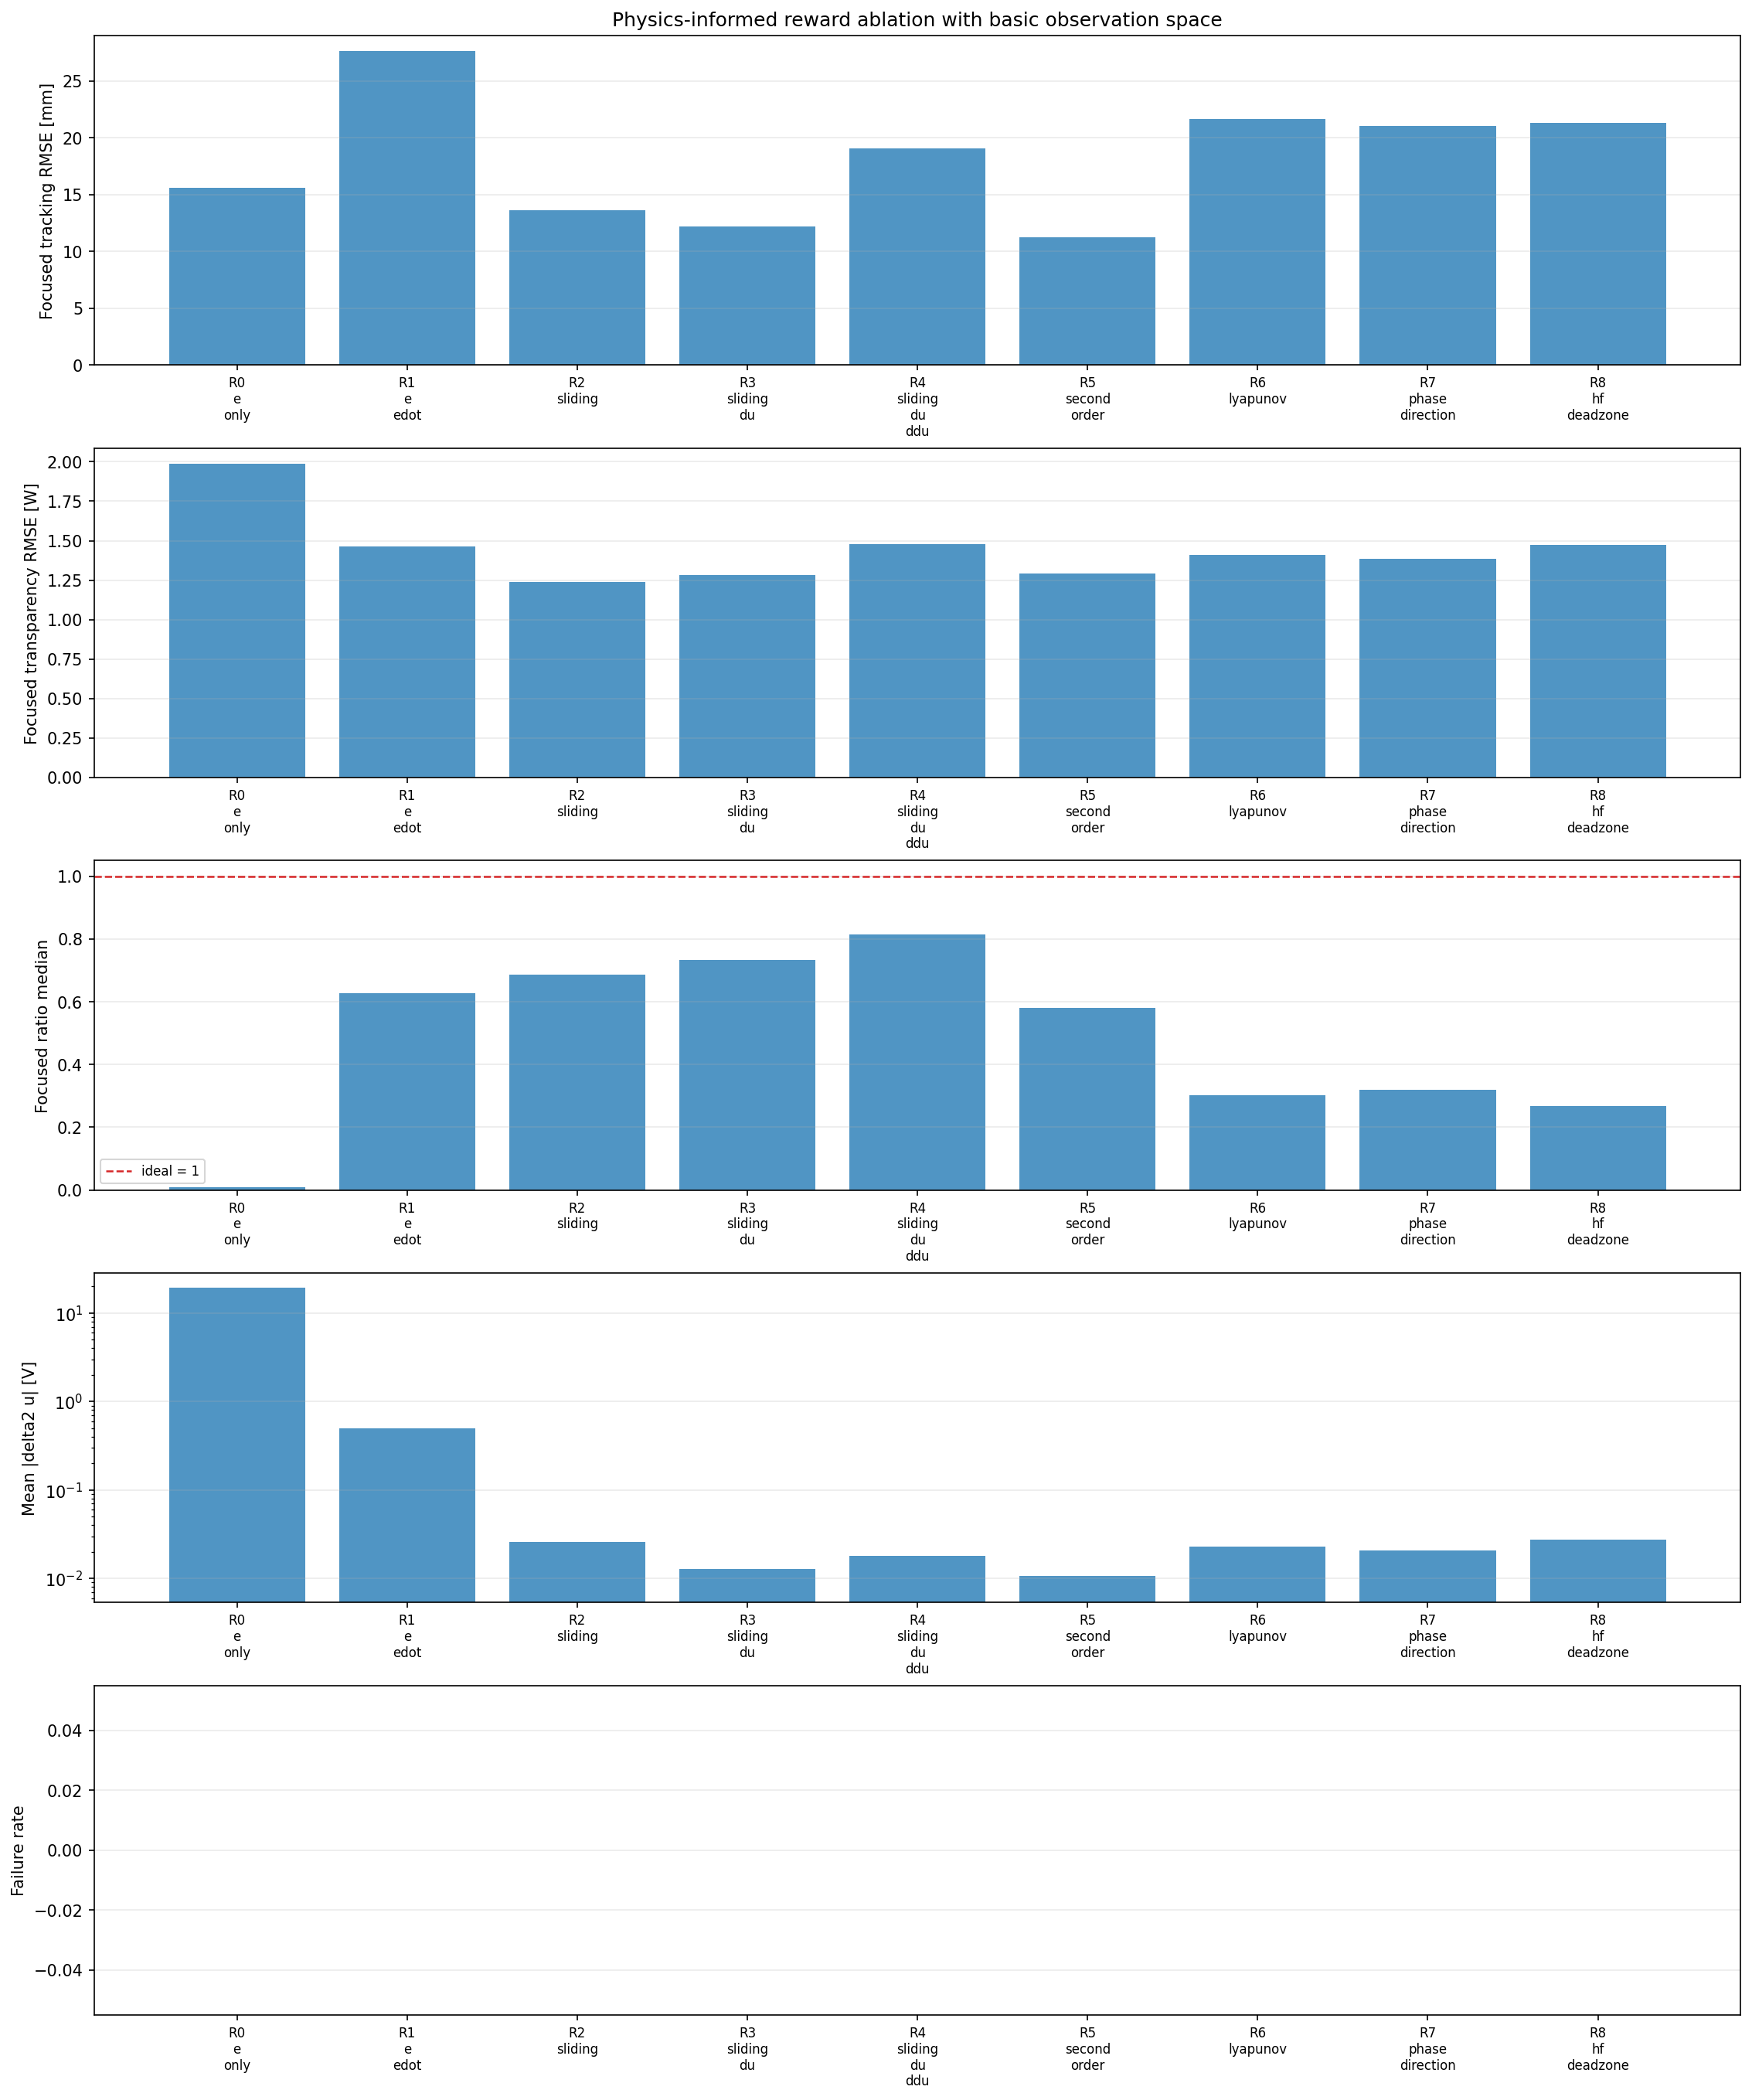

**Reward ablation training curves**

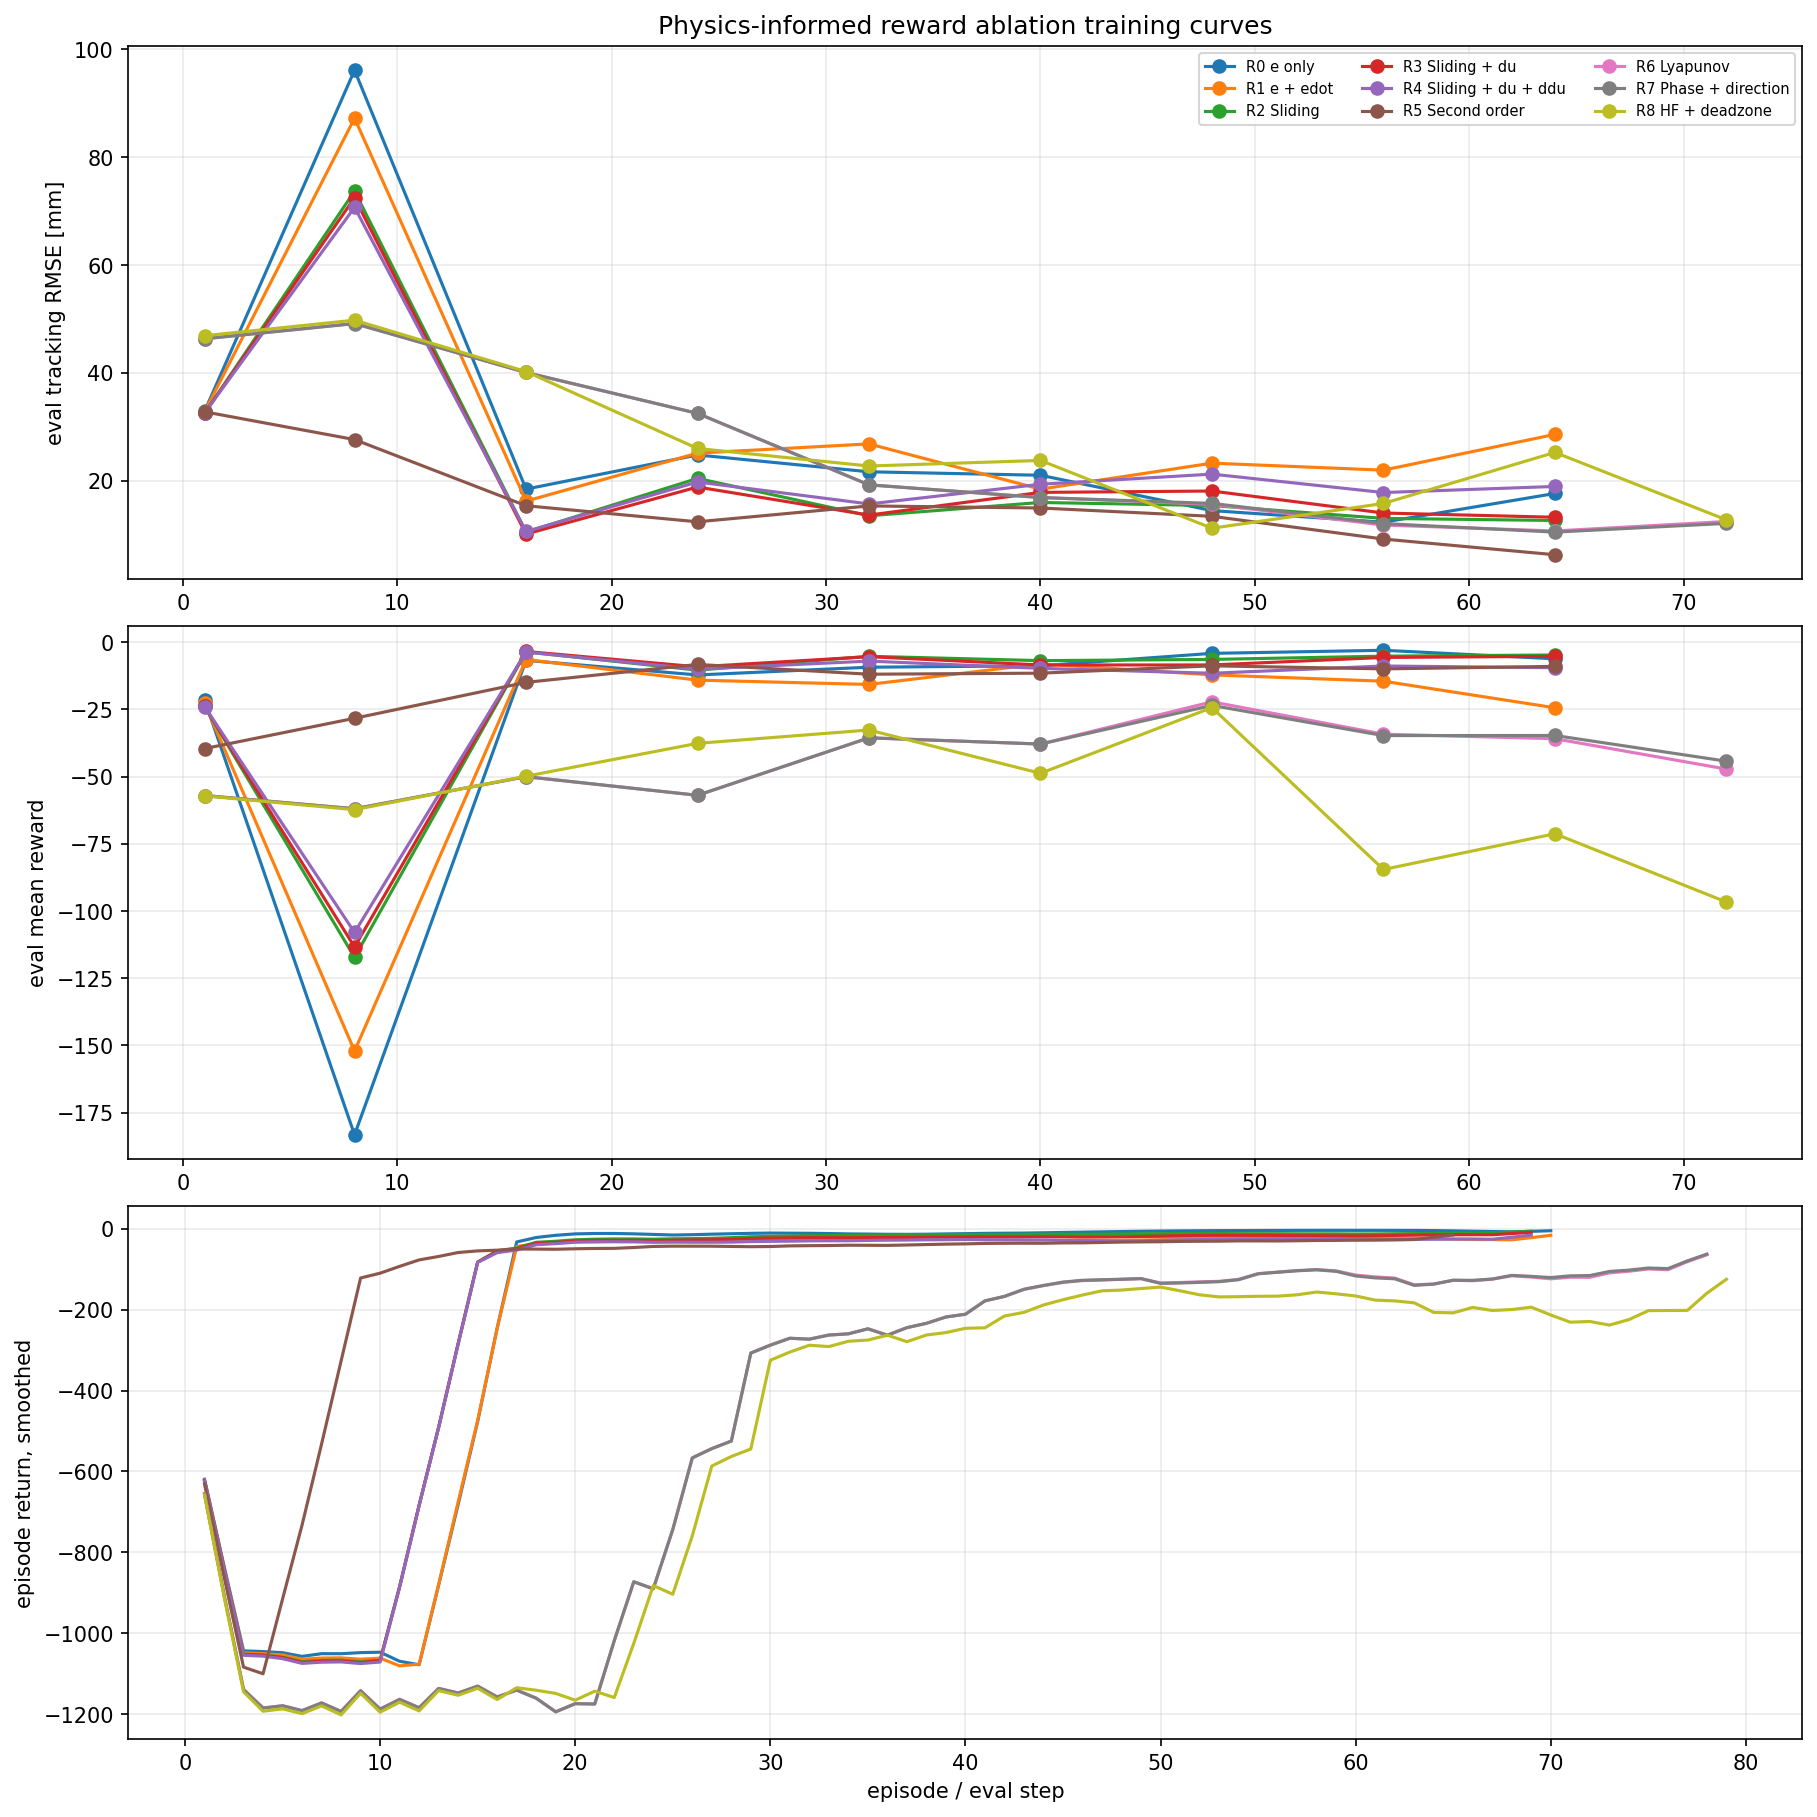

**Reward ablation group heatmap**

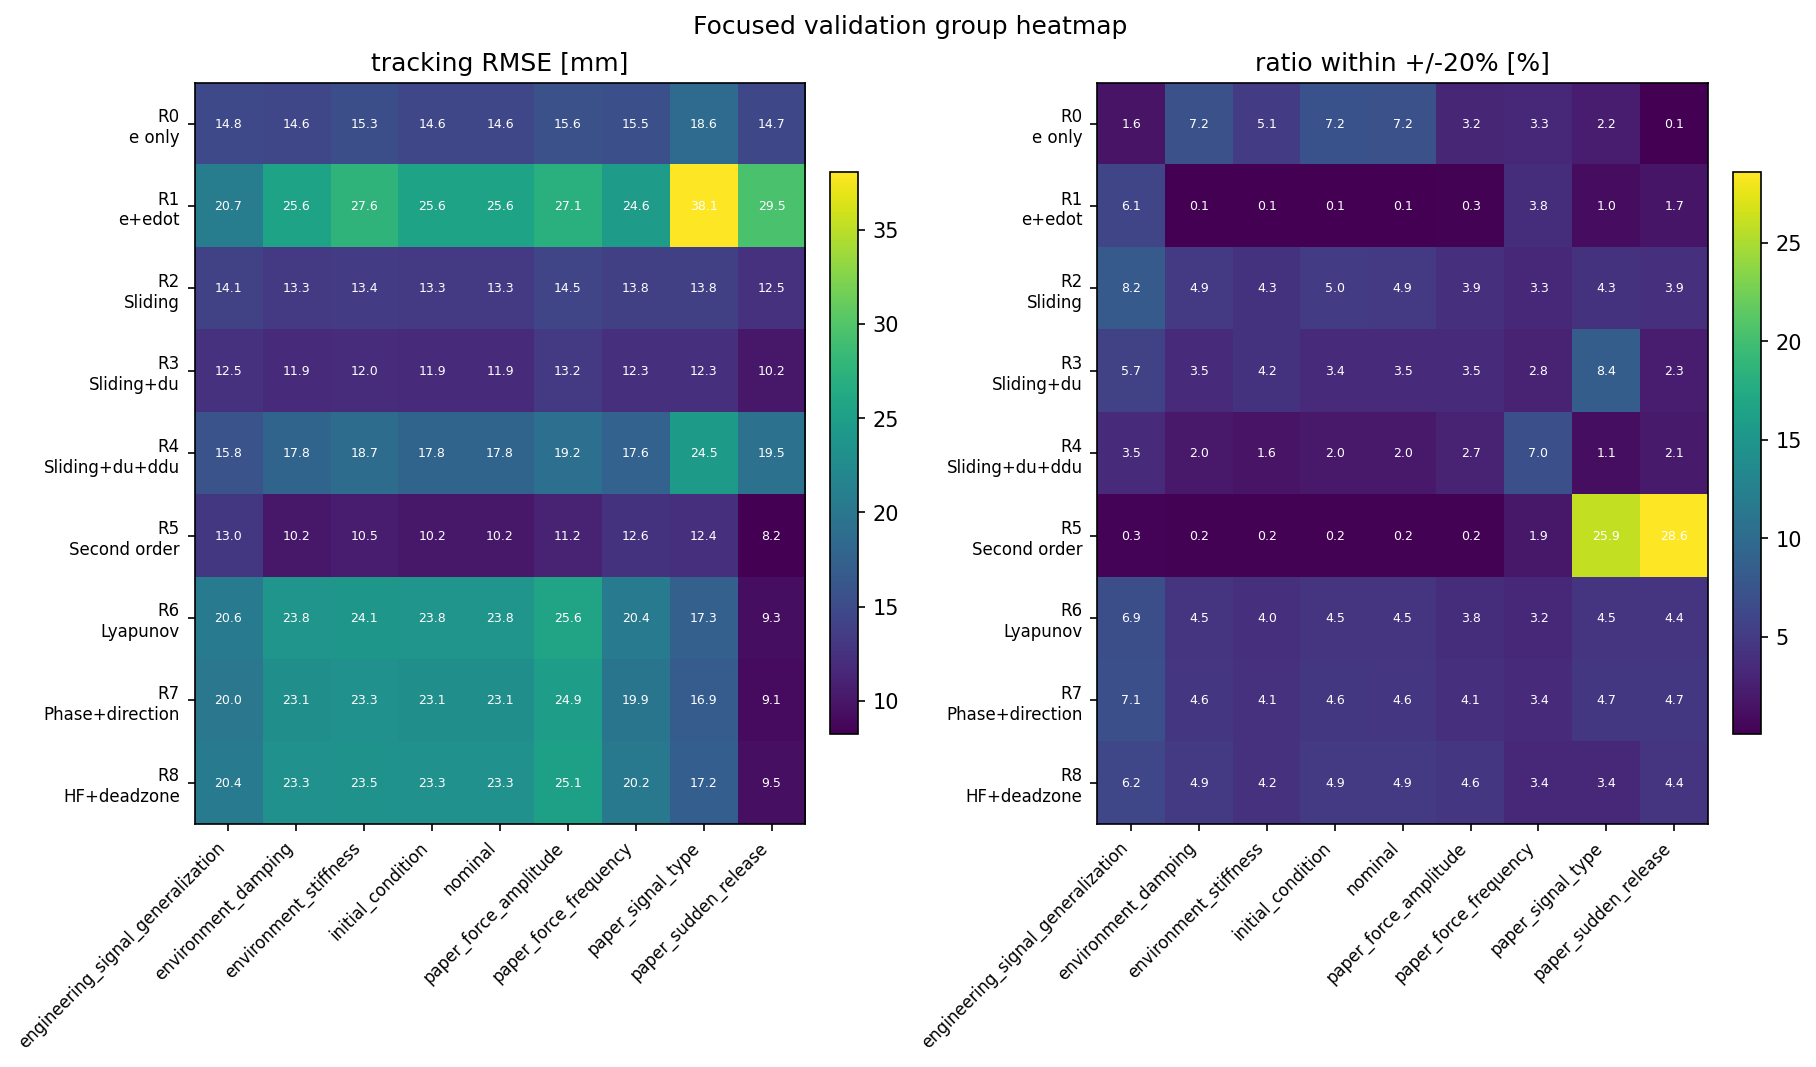

**Reward sample transparency ratio: R5 nominal**

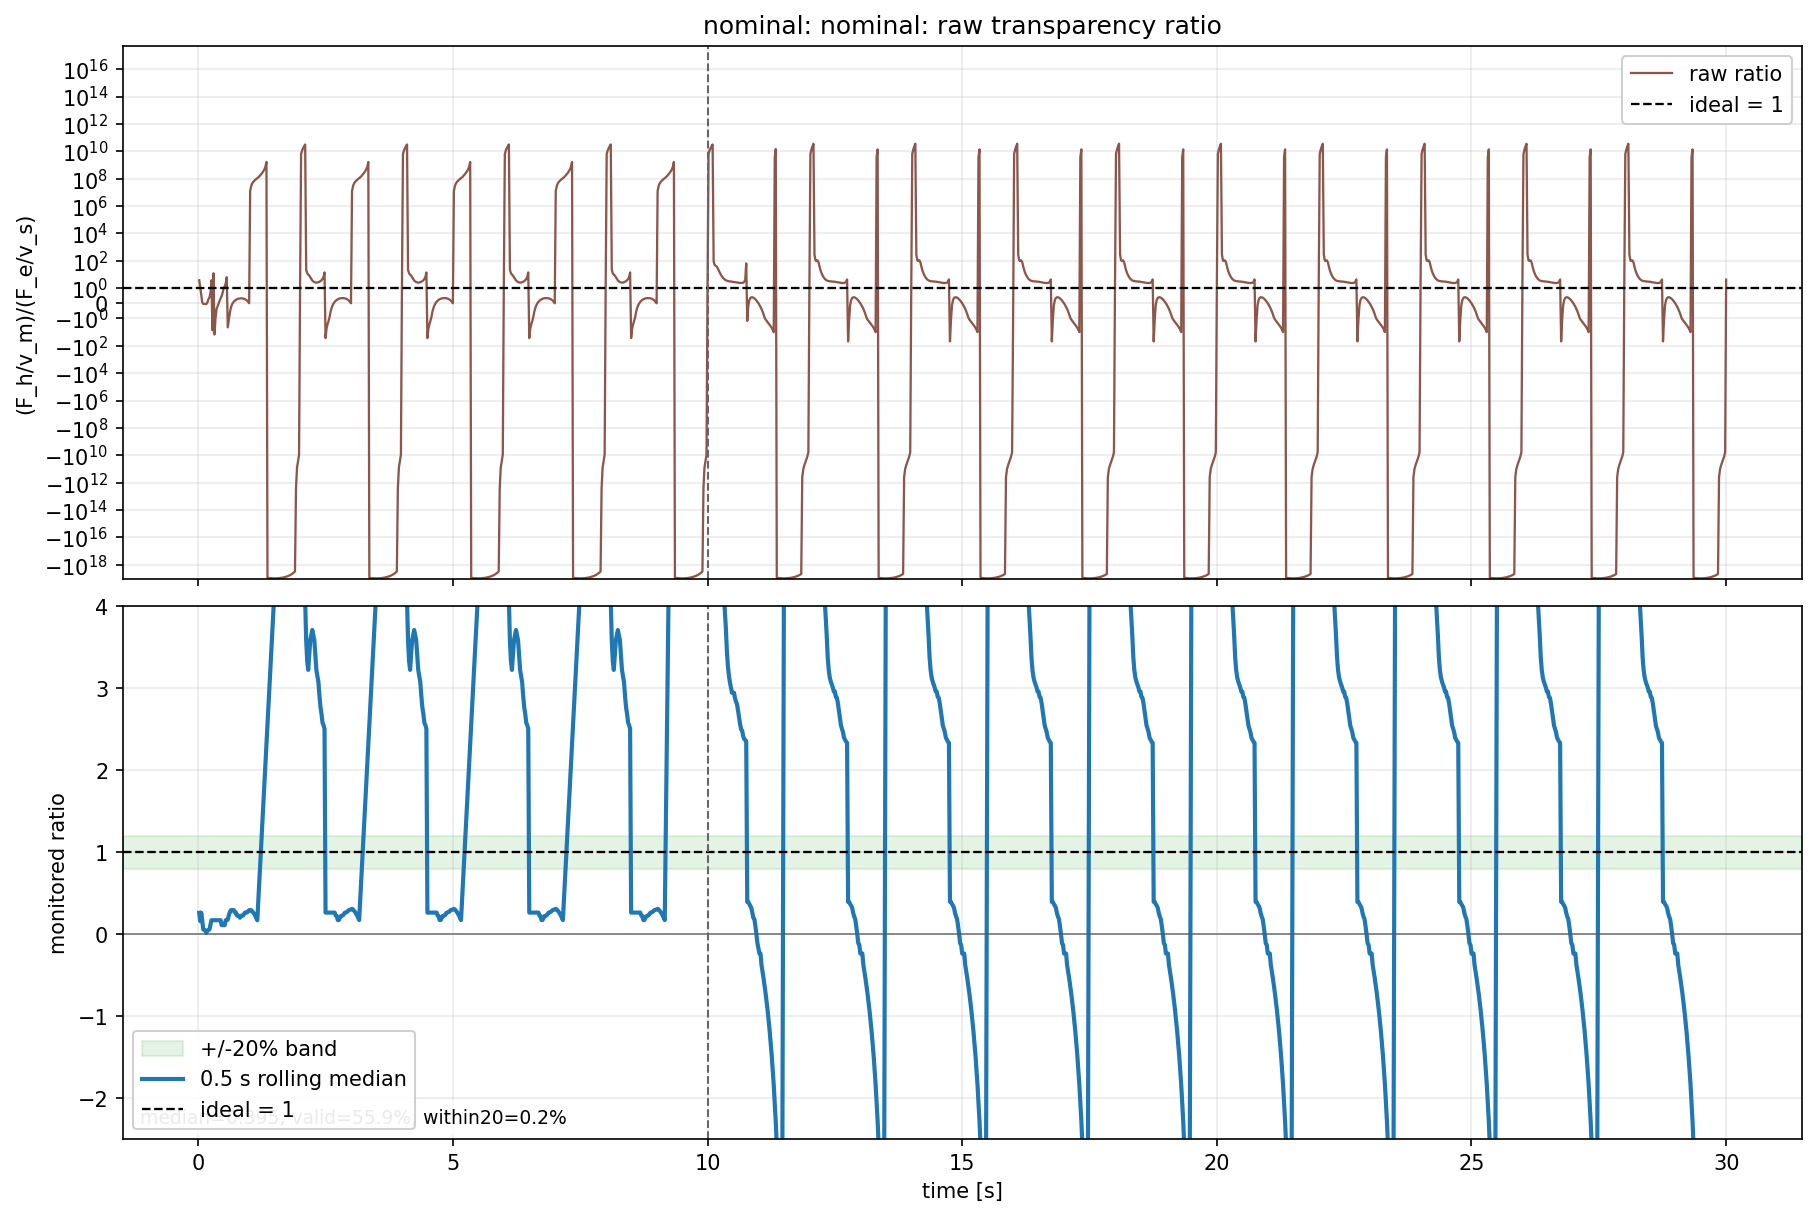

In [7]:
show_image(REWARD_DIR / "reward_ablation_summary.png", "Reward ablation summary")
show_image(REWARD_DIR / "reward_ablation_training_curves.png", "Reward ablation training curves")
show_image(REWARD_DIR / "reward_ablation_group_heatmap.png", "Reward ablation group heatmap")
show_image(REWARD_DIR / "R5_second_order" / "focused_eval" / "plots" / "scenarios" / "nominal_transparency_ratio.png", "Reward sample transparency ratio: R5 nominal")


## 3. Architecture Ablations: Inject Physics Through Temporal Access

This family changes what the policy architecture can infer from short temporal windows. It does not add privileged physics variables; instead, stacking lets the policy infer local dynamics such as finite differences.

Current status: `temporal_observation_stack_01` now includes all T0-T4 variants and focused artifacts, but it used the older 12,288-step budget. Treat this as a diagnostic architecture comparison, not as the final full-budget architecture claim.


In [8]:
arch_summary = load_summary(ARCH_DIR)
arch_audit = artifact_audit(ARCH_DIR, ARCH_KEYS)
arch_gate = summarize_gate("Architecture ablations", arch_summary, ARCH_KEYS, arch_audit)

arch_cols = ["key", "label", "obs_dim", "base_features", "lags", "total_timesteps", "focused_tracking_rmse_mm", "focused_failure_rate", "focused_transparency_ratio_error_rmse", "focused_transparency_ratio_within_20pct"]
display(arch_summary[[c for c in arch_cols if c in arch_summary.columns]].sort_values("focused_tracking_rmse_mm"))
display(arch_audit)


**Architecture ablations gate:** PASS

,gate,pass,detail
0,expected_rows,True,5 / 5 rows
1,expected_keys,True,all present
2,focused_scenarios,True,expected 25 per row
3,finite_metrics,True,"focused_tracking_rmse_mm, focused_transparency..."
4,failure_rate_range,True,"min=0, max=0.04"
5,history_artifacts,True,"min=25, max=25"
6,transparency_plots,True,"min=25, max=25"
7,scenario_pngs,True,"min=125, max=125"


,key,label,obs_dim,base_features,lags,total_timesteps,focused_tracking_rmse_mm,focused_failure_rate,focused_transparency_ratio_error_rmse,focused_transparency_ratio_within_20pct
1,T1_pos_stack3,Position Stack 3,9,x_m x_s u_v,0 1 2,12288,20.839310,0.00,12.548713,0.032599
2,T2_pos_stack5,Position Stack 5,15,x_m x_s u_v,0 1 2 3 4,12288,20.931613,0.00,22.380843,0.039055
3,T3_posvel_current,Position Velocity Current,5,x_m x_s v_m v_s u_v,0,12288,21.198635,0.00,22.540271,0.029522
0,T0_pos_current,Position Current,3,x_m x_s u_v,0,12288,30.799714,0.00,13.610786,0.051402
4,T4_posvel_stack3,Position Velocity Stack 3,15,x_m x_s v_m v_s u_v,0 1 2,12288,57.770418,0.04,15.661414,0.089629


,variant_dir,metrics_csv,history_npz_count,transparency_plot_count,scenario_png_count
0,T0_pos_current,True,25,25,125
1,T1_pos_stack3,True,25,25,125
2,T2_pos_stack5,True,25,25,125
3,T3_posvel_current,True,25,25,125
4,T4_posvel_stack3,True,25,25,125


**Architecture ablation summary**

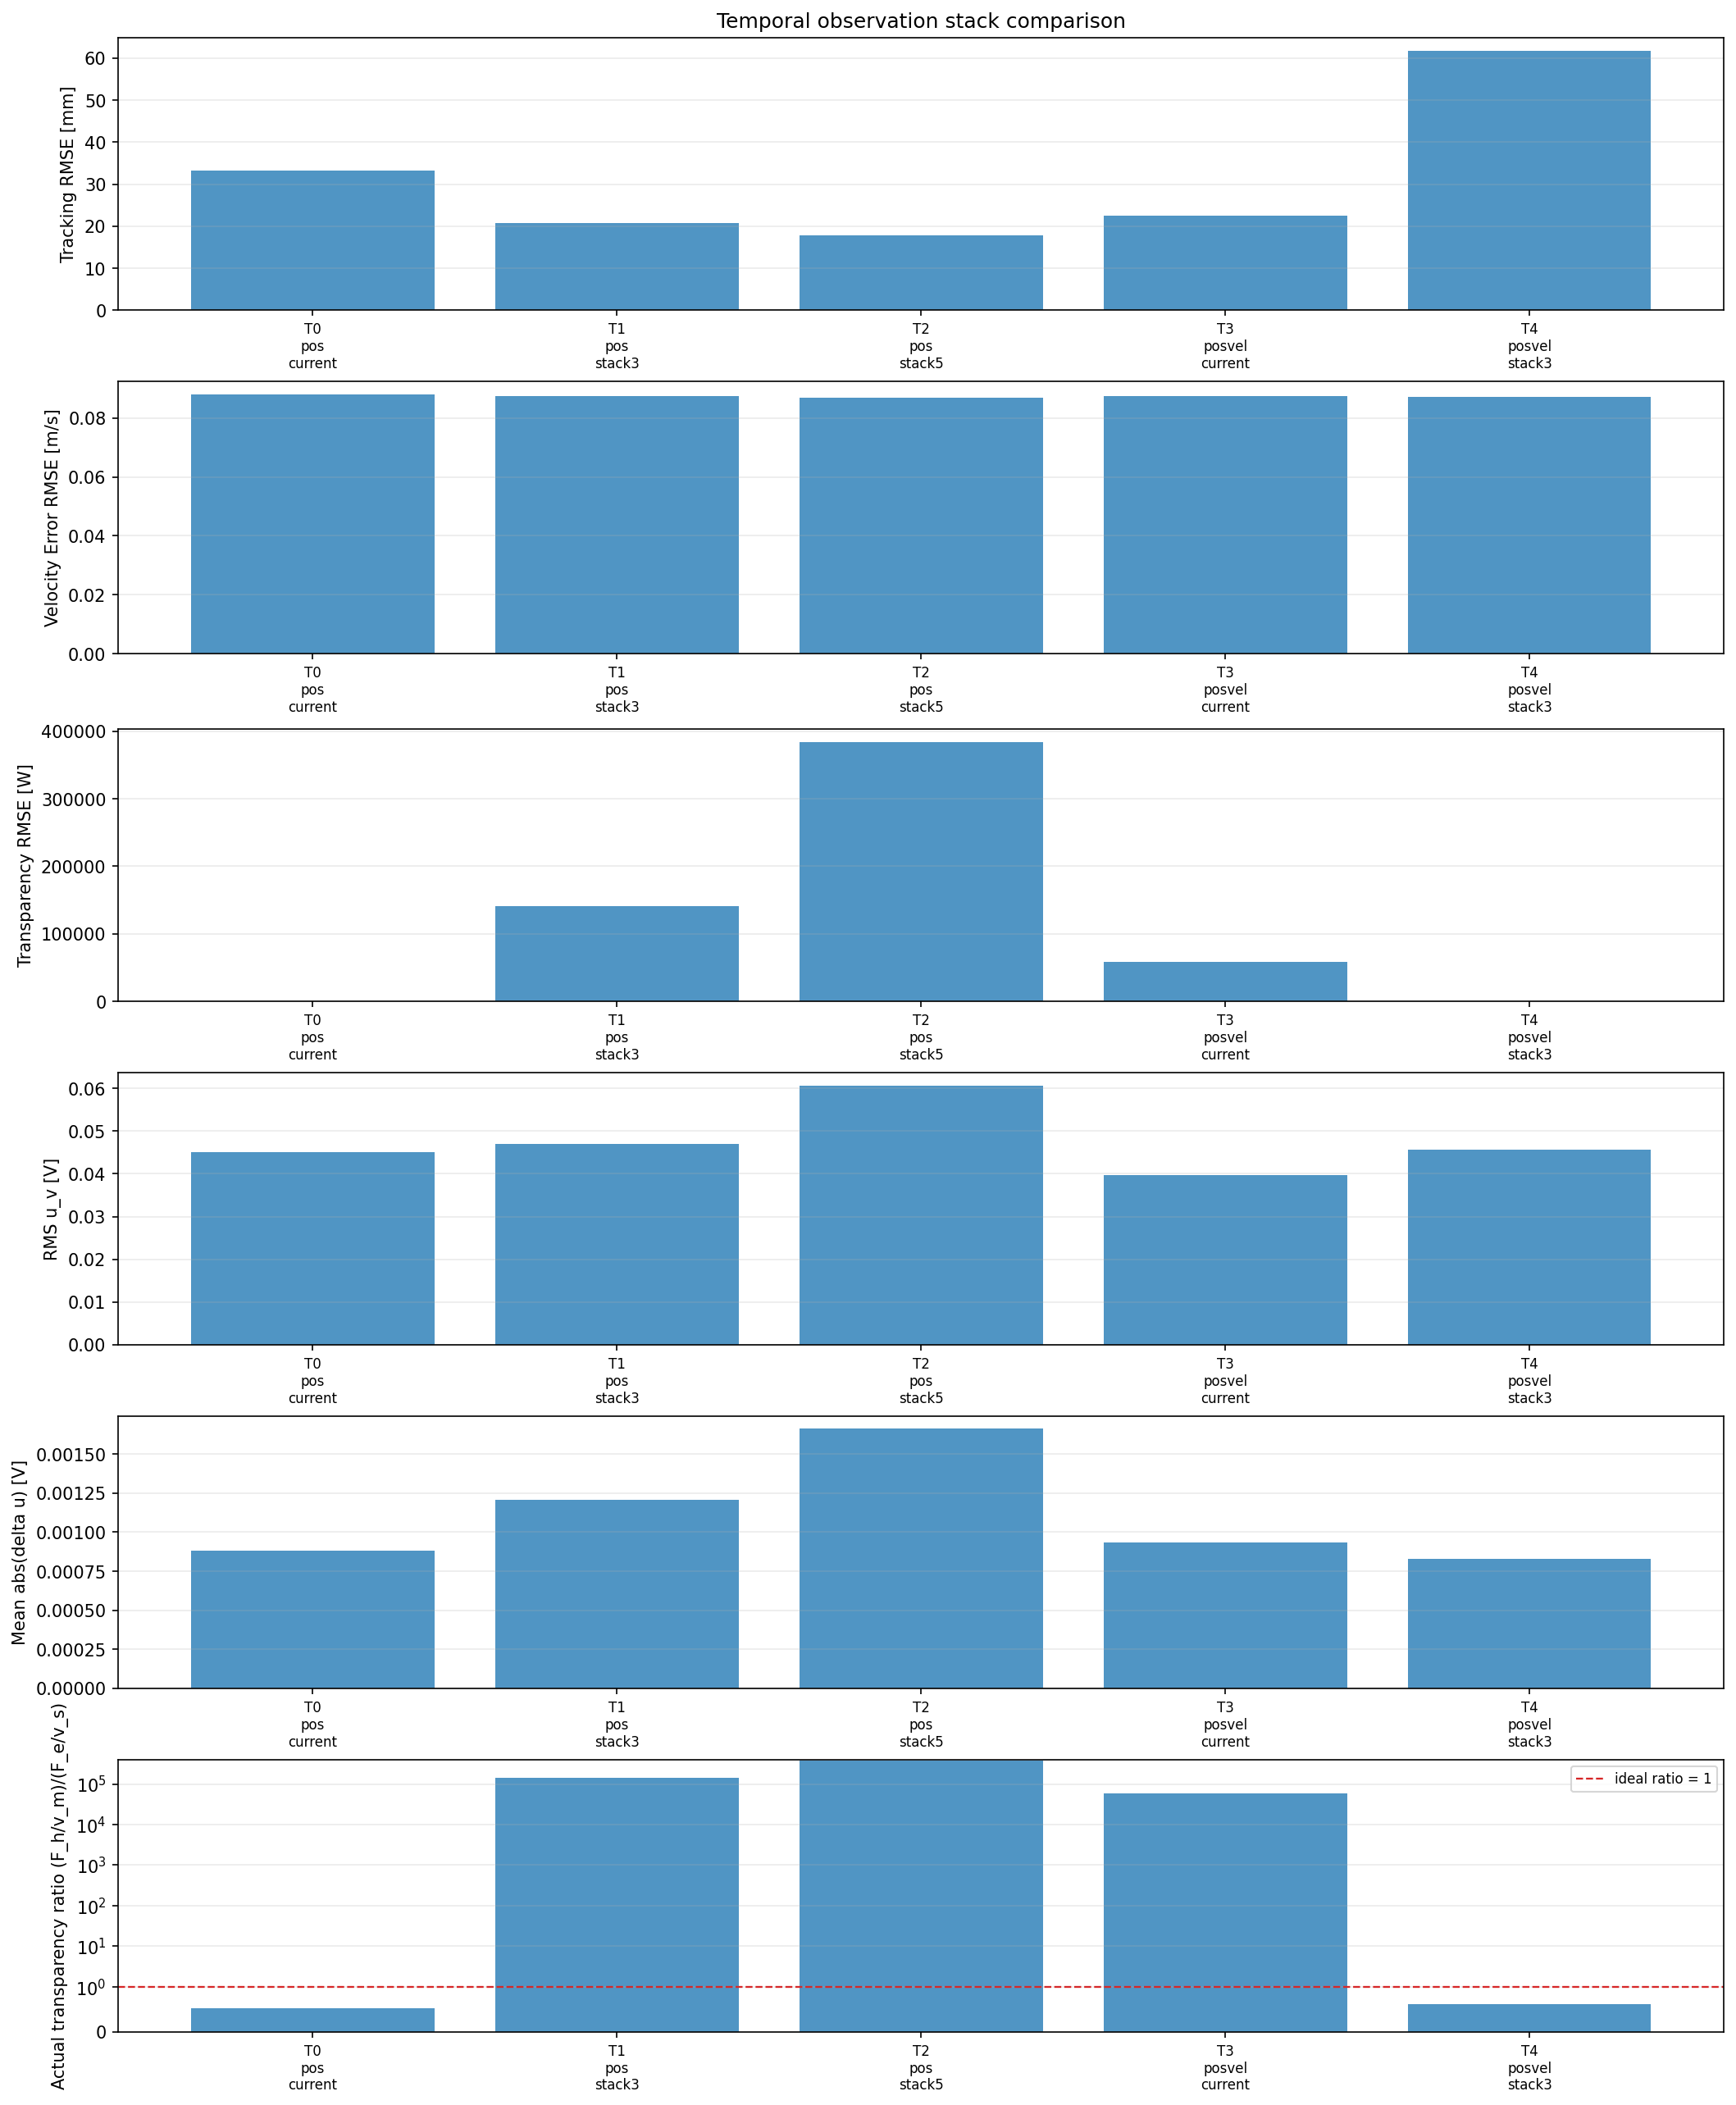

**Architecture learning curves**

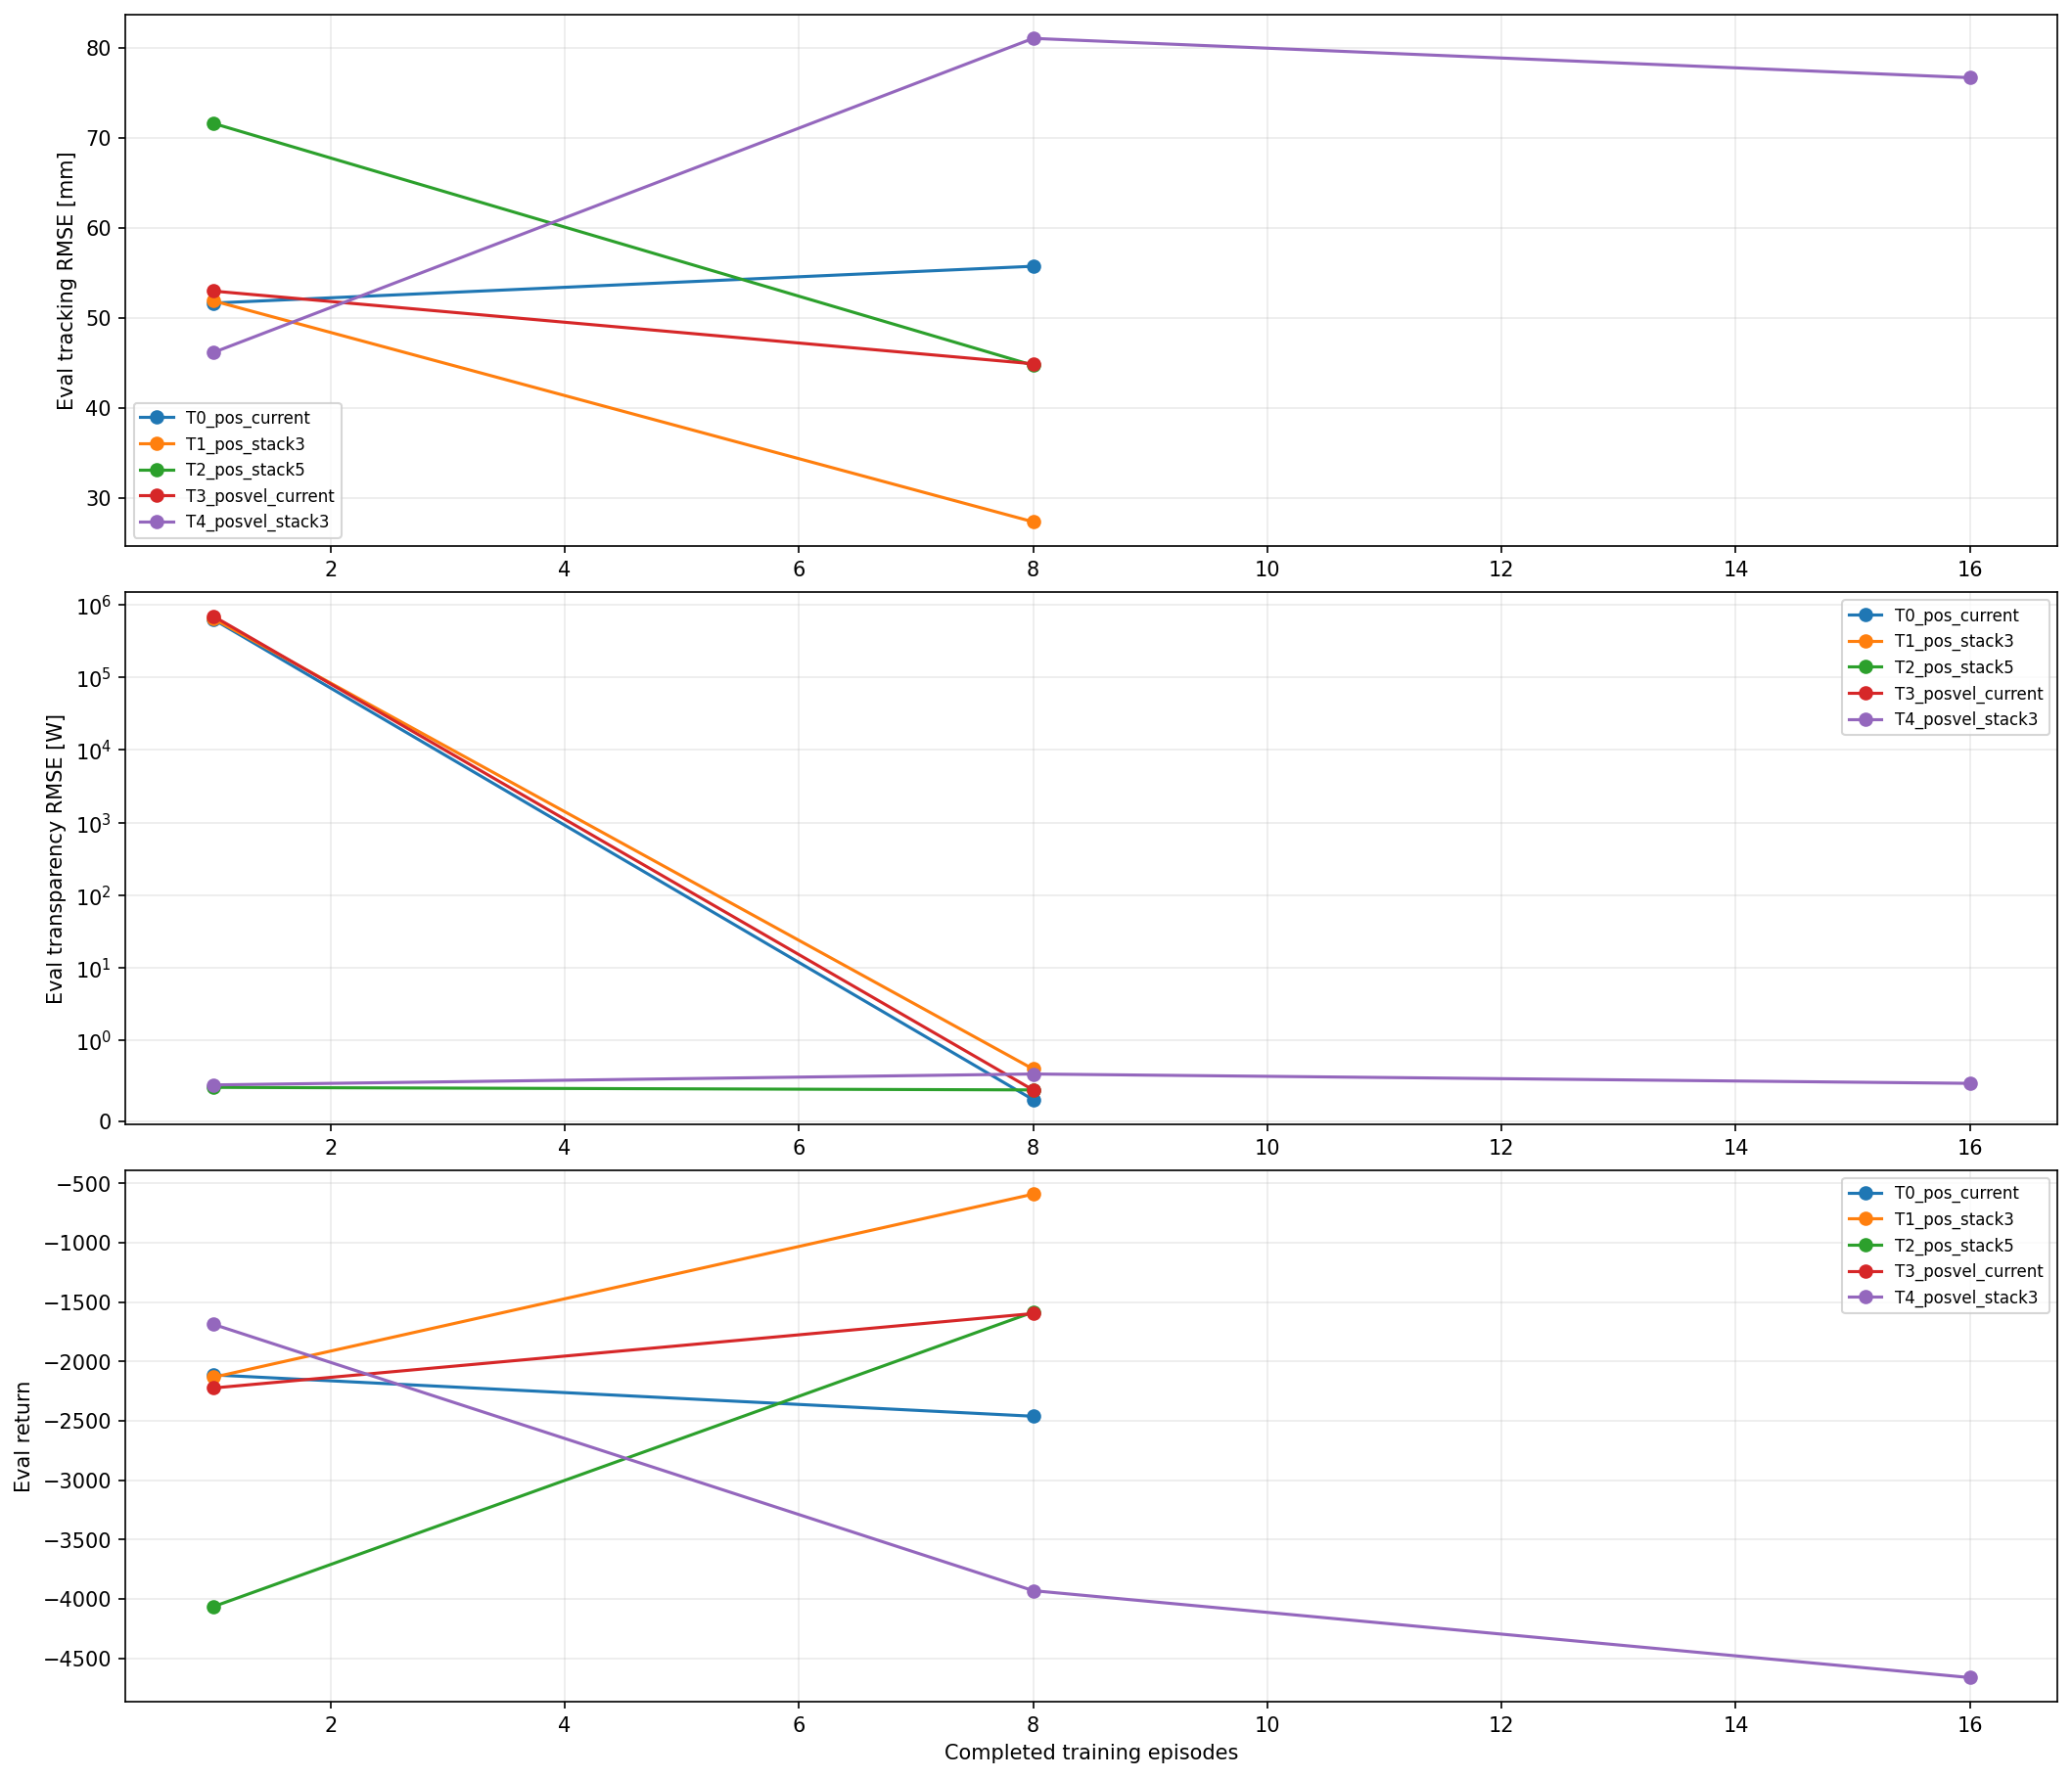

**Architecture sample transparency ratio: T1 nominal**

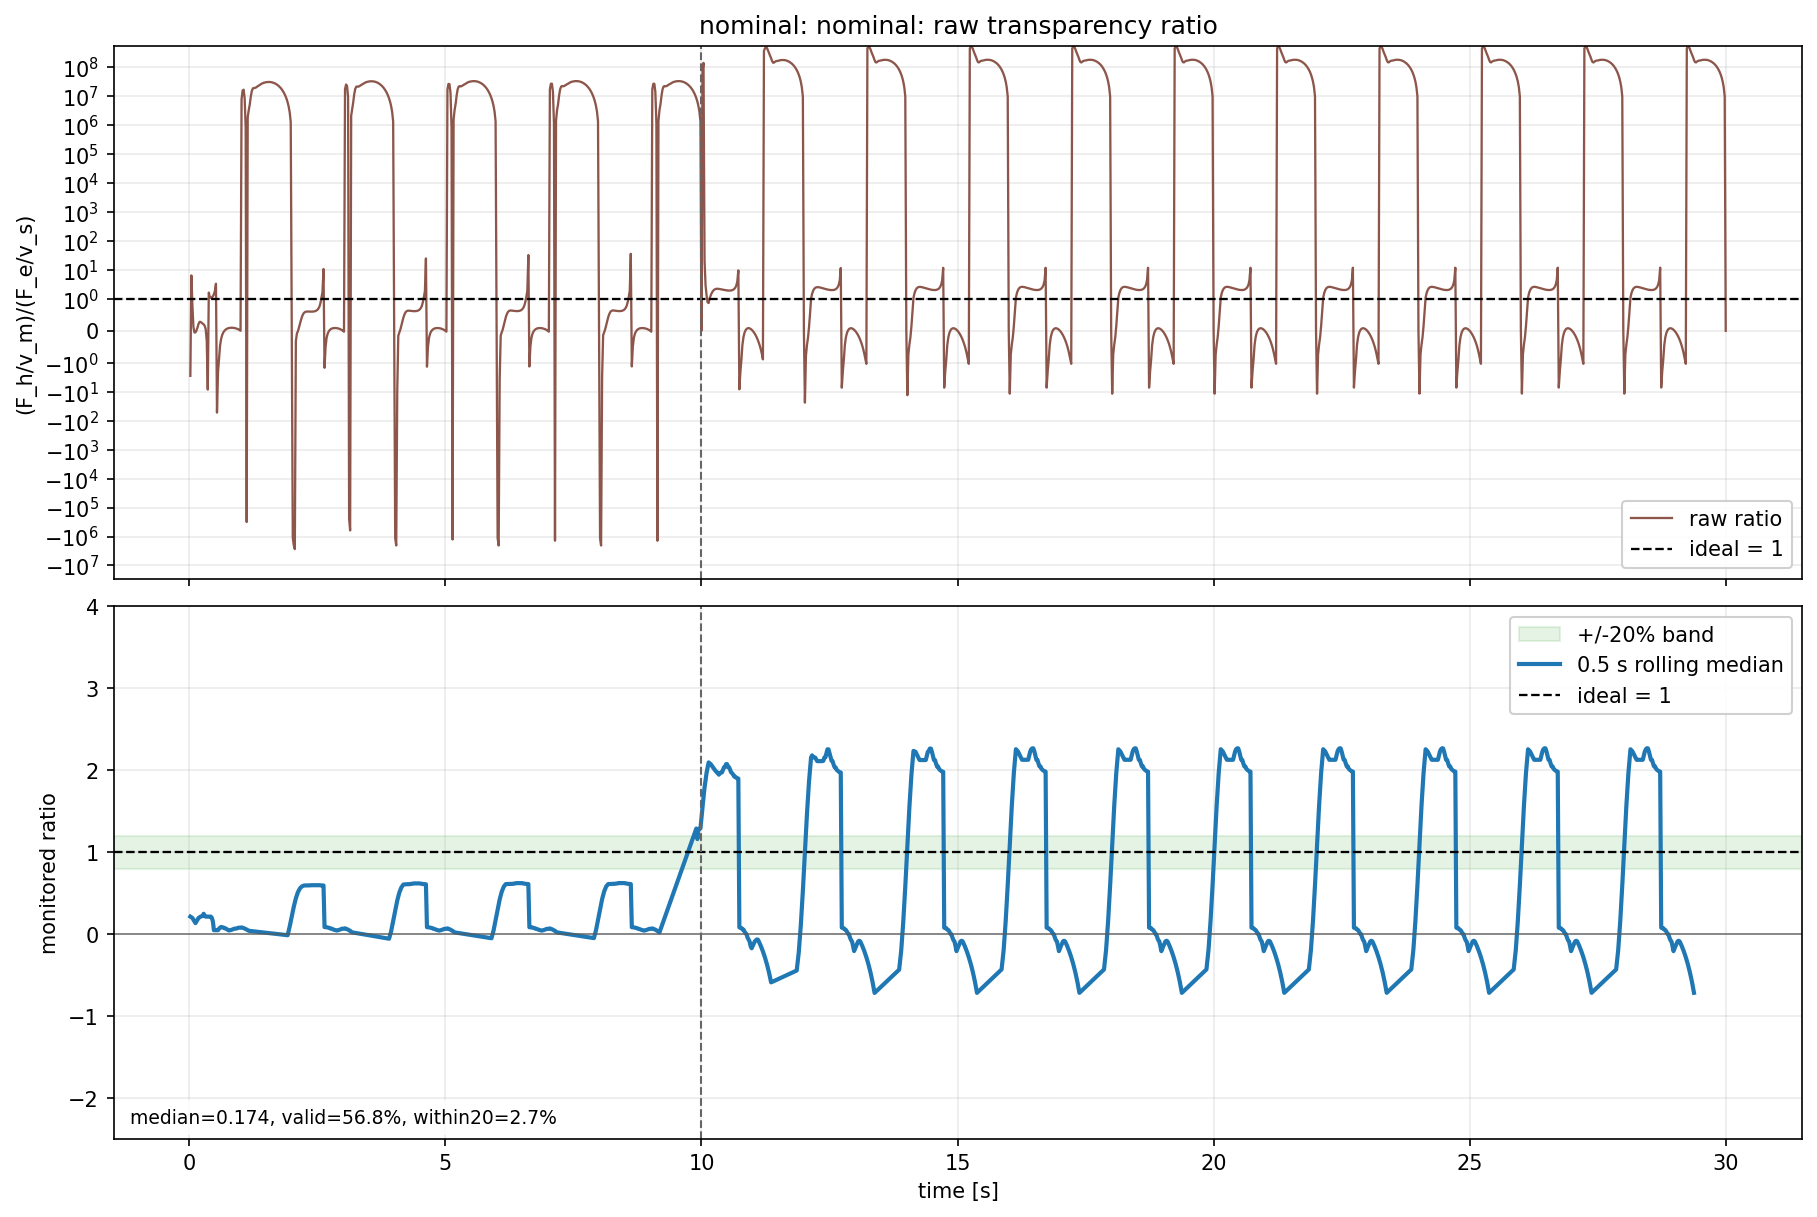

In [9]:
show_image(ARCH_DIR / "summary_bars.png", "Architecture ablation summary")
show_image(ARCH_DIR / "learning_curves.png", "Architecture learning curves")
show_image(ARCH_DIR / "T1_pos_stack3" / "focused_eval" / "plots" / "scenarios" / "nominal_transparency_ratio.png", "Architecture sample transparency ratio: T1 nominal")


## 4. Loss-Function Ablations: Inject Physics Through Training-Only Auxiliary Losses

This family keeps deployment observations basic and holds the reward fixed to `R5_second_order`. The ablation changes auxiliary losses in a GRU-PPO trainer:

- `G0`: GRU-PPO baseline.
- `G1`: prediction loss for next normalized position deltas.
- `G2`: hidden pneumatic state reconstruction loss.
- `G3`: both auxiliary losses.

This section is especially important for separating poor formulation from poor training. The auxiliary losses learn their supervised targets, but the focused failure rate remains 1.0 across all variants, so the current conclusion is a trainer/optimization problem rather than a clean loss-function rejection.


In [10]:
loss_summary = load_summary(LOSS_DIR)
loss_audit = artifact_audit(LOSS_DIR, LOSS_DIR_KEYS)
loss_gate = summarize_gate("Loss-function ablations", loss_summary, LOSS_KEYS, loss_audit)

loss_cols = ["key", "total_timesteps", "train_requested_timesteps", "train_budget_coverage", "train_finished_episodes", "train_completed_episodes", "prediction_loss_final", "hidden_state_loss_final", "focused_tracking_rmse_mm", "focused_failure_rate", "focused_transparency_ratio_error_rmse", "focused_transparency_ratio_within_20pct"]
display(loss_summary[[c for c in loss_cols if c in loss_summary.columns]].sort_values("focused_tracking_rmse_mm"))
display(loss_audit)


**Loss-function ablations gate:** PASS

,gate,pass,detail
0,expected_rows,True,4 / 4 rows
1,expected_keys,True,all present
2,focused_scenarios,True,expected 25 per row
3,finite_metrics,True,"focused_tracking_rmse_mm, focused_transparency..."
4,failure_rate_range,True,"min=1, max=1"
5,history_artifacts,True,"min=25, max=25"
6,transparency_plots,True,"min=25, max=25"
7,scenario_pngs,True,"min=125, max=125"


,key,total_timesteps,train_requested_timesteps,train_budget_coverage,train_finished_episodes,train_completed_episodes,prediction_loss_final,hidden_state_loss_final,focused_tracking_rmse_mm,focused_failure_rate,focused_transparency_ratio_error_rmse,focused_transparency_ratio_within_20pct
2,G2_gru_hidden_state,96424,96000,1.004417,988,14,0.011818,0.001550,110.437759,1.0,4.219766,0.038246
1,G1_gru_prediction,96207,96000,1.002156,864,11,0.000337,0.295646,112.757569,1.0,7.429362,0.046453
3,G3_gru_prediction_hidden,96231,96000,1.002406,1281,11,0.000653,0.010508,115.767838,1.0,2.226982,0.008143
0,G0_gru_ppo,97160,96000,1.012083,900,9,0.011968,0.295643,121.146686,1.0,20.663294,0.040464


,variant_dir,metrics_csv,history_npz_count,transparency_plot_count,scenario_png_count
0,G0,True,25,25,125
1,G1p,True,25,25,125
2,G2h,True,25,25,125
3,G3ph,True,25,25,125


**Loss-function ablation summary**

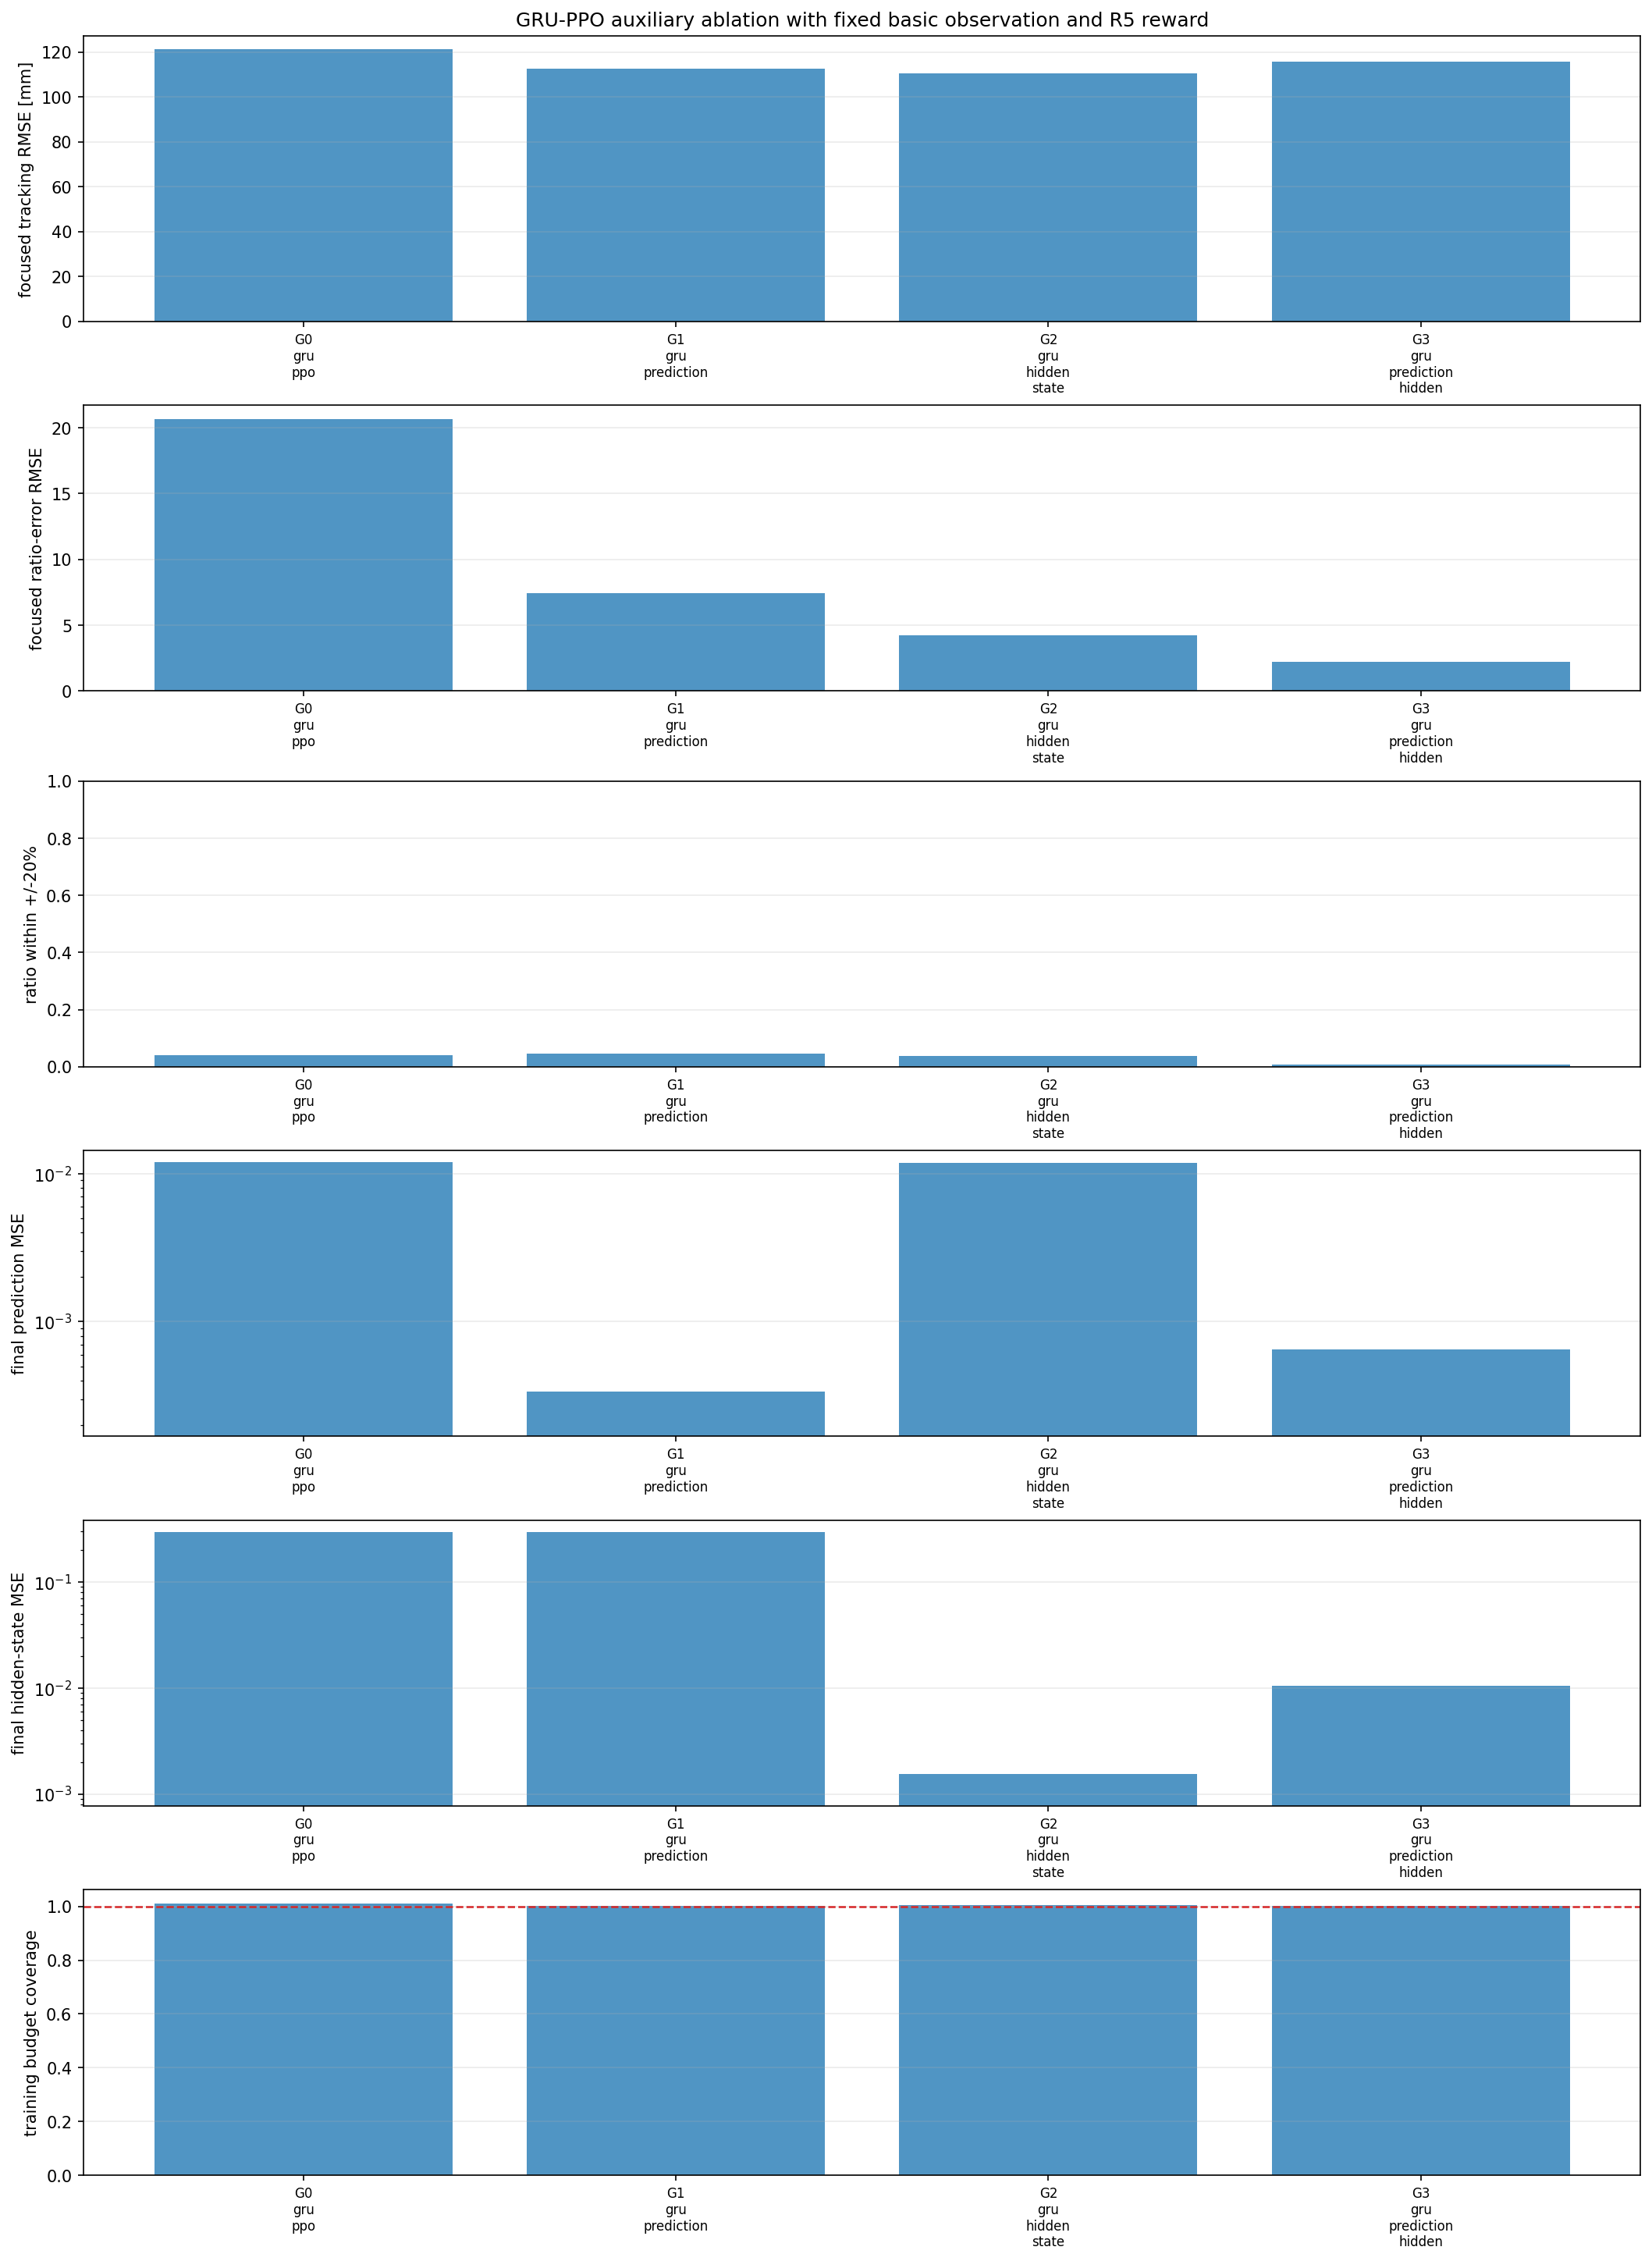

**Loss sample transparency ratio: G2 nominal**

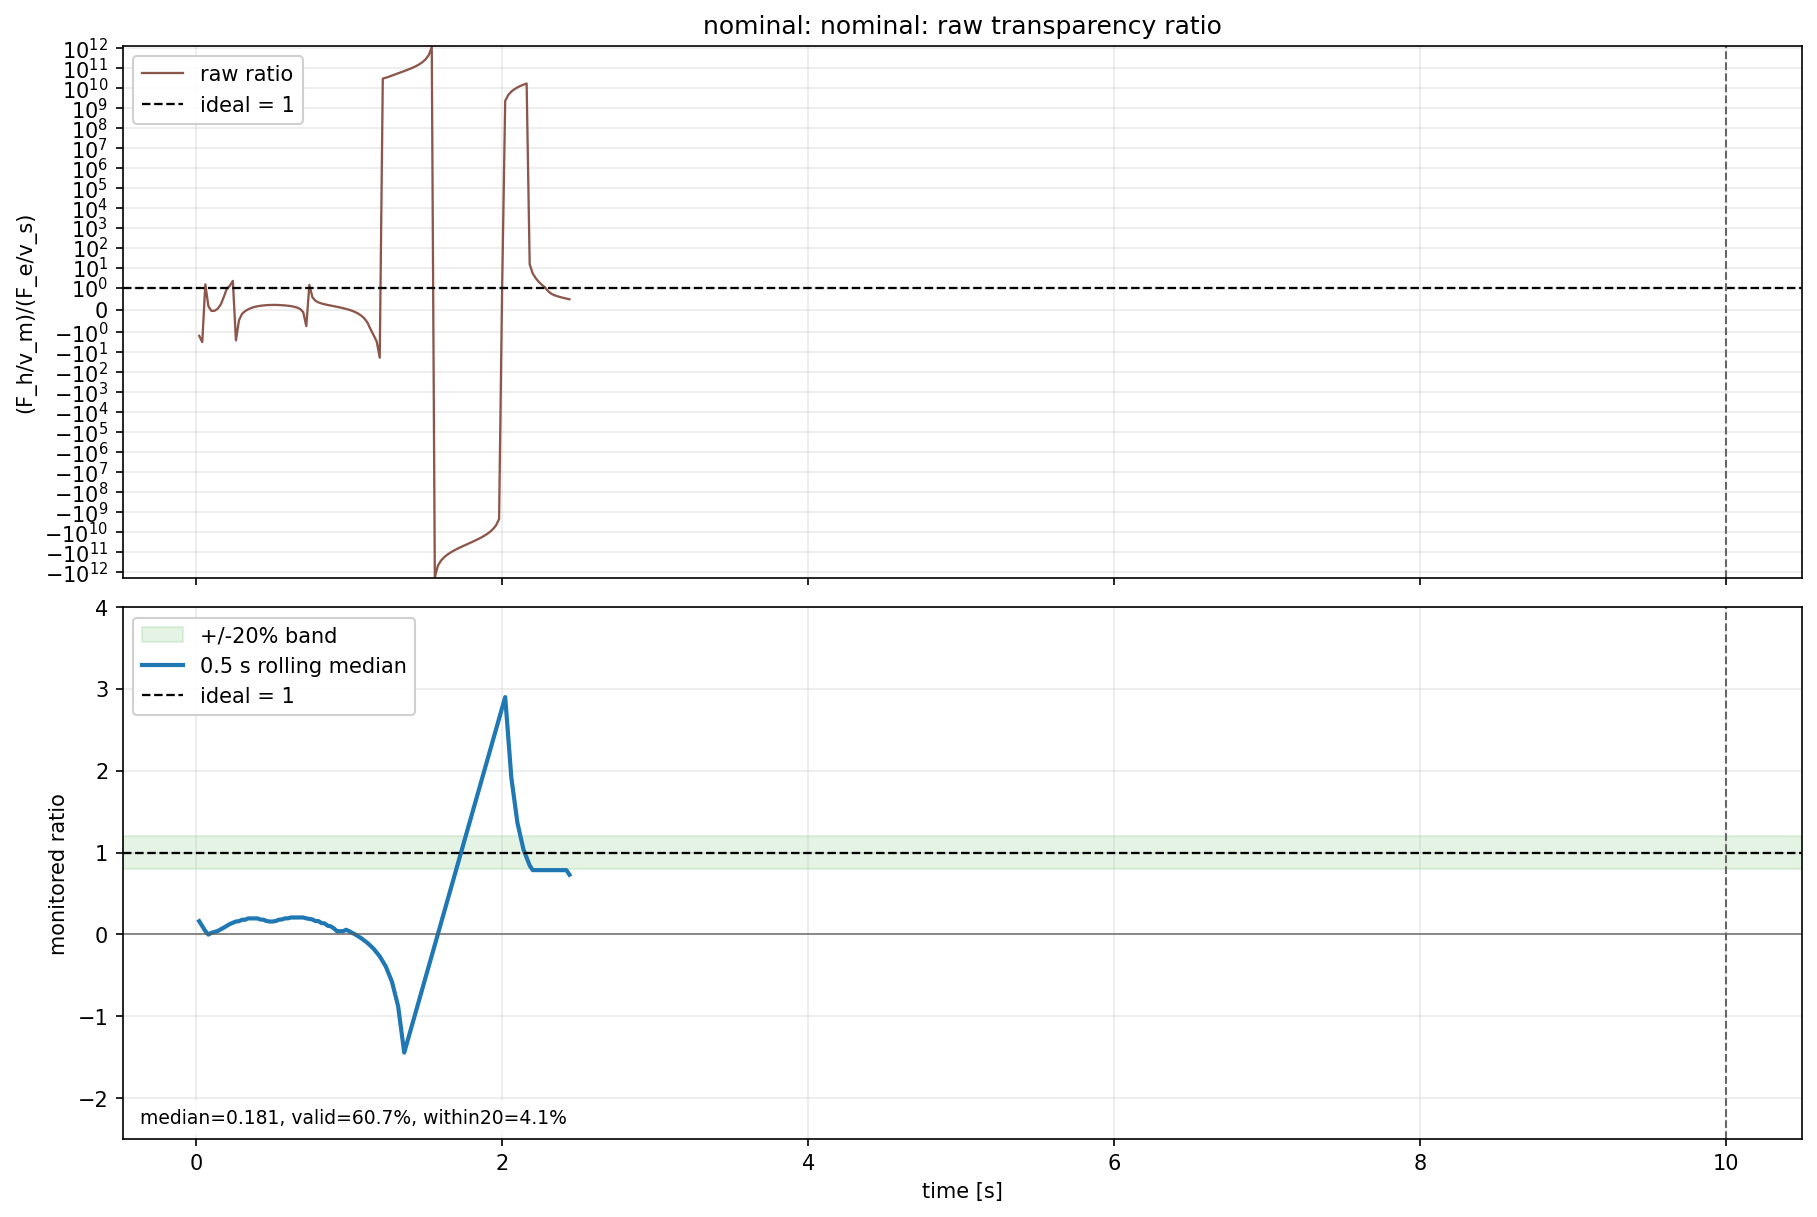

In [11]:
show_image(LOSS_DIR / "auxiliary_gru_ppo_summary.png", "Loss-function ablation summary")
show_image(LOSS_DIR / "G2h" / "focused_eval" / "plots" / "scenarios" / "nominal_transparency_ratio.png", "Loss sample transparency ratio: G2 nominal")


## Cross-Family Interpretation

The tables below intentionally compare both performance and training health. A formulation with poor tracking but clean training/focused artifacts is a candidate negative result. A family with failed training gates, missing artifacts, or universal focused failures is treated as a training/plumbing issue before it is treated as a physics-formulation result.


In [12]:
def family_best_rows() -> pd.DataFrame:
    rows = []
    for family, df, note in [
        ("state", state_summary, "original 24,576-step F0-F6 study"),
        ("reward", reward_summary, "basic observation, 96,000-step reward-only ablation"),
        ("architecture", arch_summary, "diagnostic 12,288-step temporal-stack study"),
        ("loss", loss_summary, "GRU-PPO auxiliary losses, fixed 96,000-transition budget"),
    ]:
        best_track = df.sort_values("focused_tracking_rmse_mm").iloc[0]
        best_ratio = df.sort_values("focused_transparency_ratio_error_rmse").iloc[0]
        rows.append({
            "family": family,
            "best_tracking_key": best_track["key"],
            "best_tracking_rmse_mm": best_track["focused_tracking_rmse_mm"],
            "best_ratio_key": best_ratio["key"],
            "best_ratio_error_rmse": best_ratio["focused_transparency_ratio_error_rmse"],
            "max_failure_rate": pd.to_numeric(df["focused_failure_rate"], errors="coerce").max(),
            "note": note,
        })
    return pd.DataFrame(rows)

family_comparison = family_best_rows()
display(family_comparison)

all_gates = pd.concat({
    "state": state_gate.set_index("gate"),
    "reward": reward_gate.set_index("gate"),
    "architecture": arch_gate.set_index("gate"),
    "loss": loss_gate.set_index("gate"),
}, names=["family", "gate"]).reset_index()
display(all_gates)


,family,best_tracking_key,best_tracking_rmse_mm,best_ratio_key,best_ratio_error_rmse,max_failure_rate,note
0,state,F2_error_dot_state_reward,8.053667,F5_accel_state_reward,29.425164,0.00,"original 24,576-step F0-F6 study"
1,reward,R5_second_order,11.223918,R2_sliding,16.029764,0.00,"basic observation, 96,000-step reward-only abl..."
2,architecture,T1_pos_stack3,20.839310,T1_pos_stack3,12.548713,0.04,"diagnostic 12,288-step temporal-stack study"
3,loss,G2_gru_hidden_state,110.437759,G3_gru_prediction_hidden,2.226982,1.00,"GRU-PPO auxiliary losses, fixed 96,000-transit..."


,family,gate,pass,detail
0,state,expected_rows,True,7 / 7 rows
1,state,expected_keys,True,all present
2,state,focused_scenarios,True,expected 25 per row
3,state,finite_metrics,True,"focused_tracking_rmse_mm, focused_transparency..."
4,state,failure_rate_range,True,"min=0, max=0"
5,state,history_artifacts,True,"min=25, max=25"
6,state,transparency_plots,True,"min=25, max=25"
7,state,scenario_pngs,True,"min=125, max=125"
8,reward,expected_rows,True,9 / 9 rows
9,reward,expected_keys,True,all present


## Current Conclusions

- **State injection**: adding error and velocity-error coordinates improves tracking in the original F0-F6 budget. `F2_error_dot_state_reward` is the best state-family tracking result.
- **Reward injection**: with the basic observation fixed, `R5_second_order` is best for focused tracking, while `R2_sliding` is best for transparency-ratio error. This supports encoding desired error dynamics in the reward, not merely penalizing instantaneous error.
- **Architecture injection**: the temporal-stack study is now complete as a diagnostic run, but its 12,288-step budget is much smaller than the reward/loss studies. `T4_posvel_stack3` underperforms here, so this family should get a full-budget rerun before making a final architecture claim.
- **Loss-function injection**: auxiliary prediction/hidden-state losses reduce their supervised losses, but every GRU-PPO variant fails the focused suite. That points to the custom recurrent PPO trainer/optimization loop rather than a clean rejection of auxiliary physics losses.


In [13]:
artifact_rollup = pd.concat([
    artifact_audit(STATE_DIR, STATE_KEYS).assign(family="state"),
    artifact_audit(REWARD_DIR, REWARD_KEYS).assign(family="reward"),
    artifact_audit(ARCH_DIR, ARCH_KEYS).assign(family="architecture"),
    artifact_audit(LOSS_DIR, LOSS_DIR_KEYS).assign(family="loss"),
], ignore_index=True)
display(artifact_rollup[["family", "variant_dir", "metrics_csv", "history_npz_count", "transparency_plot_count", "scenario_png_count"]])

assert state_gate["pass"].all(), "State gate failed"
assert reward_gate["pass"].all(), "Reward gate failed"
assert arch_gate["pass"].all(), "Architecture gate failed"
assert loss_gate["pass"].all(), "Loss gate failed"


,family,variant_dir,metrics_csv,history_npz_count,transparency_plot_count,scenario_png_count
0,state,F0_baseline,True,25,25,125
1,state,F1_error_state_reward,True,25,25,125
2,state,F2_error_dot_state_reward,True,25,25,125
3,state,F3_error_ddot_state_reward,True,25,25,125
4,state,F4_accel_state,True,25,25,125
5,state,F5_accel_state_reward,True,25,25,125
6,state,F6_effort_plus_delta_u,True,25,25,125
7,reward,R0_e_only,True,25,25,125
8,reward,R1_e_edot,True,25,25,125
9,reward,R2_sliding,True,25,25,125
